In [ ]:
# ПОДГРУЖАЕМ ВСЕ НЕОБХОДИМЫЕ БИЛИОТЕКИ

import requests as r
import selenium as sl
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.webdriver.common.action_chains import ActionChains
import pandas as pd
from bs4 import BeautifulSoup
import time
import json
from datetime import datetime
import random
import re
from tqdm import tqdm

# ПАРСИНГ ДАННЫХ

### Часть 1: собираем ссылки на заведения

In [ ]:
# ОБЩИЙ ПАРСЕР ССЫЛОК ДЛЯ НЕСКОЛЬКИХ ГОРОДОВ

list_of_cities = {}
with open('urls.txt', 'r', encoding='utf-8') as f:
    for line in f:
        s = line.split(',')
        list_of_cities[s[0]] = s[1]

list_of_cities

{'Тюмень': 'https://yandex.ru/maps/55/tyumen/search/Где%20поесть/?ll=65.635458%2C57.157209&sctx=ZAAAAAgBEAAaKAoSCVvri4S2ZlBAEVEtIorJk0xAEhIJY7ml1ZC44T8RK%2FwZ3qzBxT8iBgABAgMEBSgKOABAk40GSAFiRnJlYXJyPXNjaGVtZV9Mb2NhbC9HZW91cHBlci9BZHZlcnRzL1JlYXJyYW5nZUJ5QXVjdGlvbi9DYWNoZS9FbmFibGVkPTFiSXJlYXJyPXNjaGVtZV9Mb2NhbC9HZW91cHBlci9BZHZlcnRzL1JlYXJyYW5nZUJ5QXVjdGlvbi9DYWNoZS9ab29tTGltaXQ9MTVqAnJ1nQHNzMw9oAEAqAEAvQFwh4NswgGKAdaIt5DEBf7G%2FvLTBuaWvZDqBpGm%2Ft3pBeD3zdbABf6%2BhYRGw6ij22zRofqRBcWQuZkFrYrG4TP0oemKOYPfyJs29%2FTn65sF3a%2BzuZMFt7DY1v0Emqvg%2BgSA5dmrgQbinNzT1wbV%2B8qx%2FAOPsv%2FwBv%2BPt%2FUE6%2F7x7sICjtj86yWDjM%2FyBLXbqKG9AYICE9CT0LTQtSDQv9C%2B0LXRgdGC0YyKAlwxODQxMDYzOTAkMTg0MTA2Mzg2JDE4NDEwNjM5NiQxODQxMDYzOTIkMTg0MTA2Mzg0JDE4NDEwNjM5NCQzNTE5MzExNDkzNyQxMzg3Nzg4OTk2JDc3MDkzMTUzN5ICAJoCDGRlc2t0b3AtbWFwc6oCvwE0Njk0NjQ5ODk4OSwxNDE3NTQ5NjQyLDE0NzQ1MTM0NTM3Miw2MTkxNDg5ODA0NywxOTAzNTE4NTQ0NzMsNjAwMjM0NywxNjg0MTczODg3NzYsNzA4OTEyNjY1MDIsMTk5OTIxNjYzMzk3LDgzMjgwNzI3NjksNTg5OTM0Mjk1NDYsMjA5MTAxOD

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")


for city, city_url in list_of_cities.items():
    driver = webdriver.Chrome(options=options)
    wait = WebDriverWait(driver, 10)
    driver.get(city_url)
    time.sleep(random.uniform(3, 6))
    # driver.find_element(By.XPATH, "(//div[@class='catalog-grid-view__icon'])[2]").click()
    # time.sleep(random.uniform(3, 6))

    try:
        scroll_container = driver.find_element(By.CSS_SELECTOR, "div.scroll__container")
    except:
        scroll_container = driver.find_element(By.CSS_SELECTOR, "div[class*='search-list-view']")

    collected_hrefs = set()
    last_height = 0
    no_new_items_counter = 0
    max_no_new = 3            # КРИТЕРИЙ ОСТАНОВА - ЕСЛИ 3 РАЗА ПОДРЯД ССЫЛКИ НЕ ОБНОВЛЯЛИСЬ

    while True:
        # ПРОКРУТКА КОНТЕЙНЕРА
        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight;", scroll_container)
        time.sleep(random.uniform(3, 6))

        # СБОР ССЫЛОК НА ЗАВЕДЕНИЯ
        link_elements = driver.find_elements(By.CSS_SELECTOR, "a.search-business-snippet-view__link-overlay")
        new_hrefs = {el.get_attribute("href") for el in link_elements if el.get_attribute("href")}

        link_elements = driver.find_element(By.CLASS_NAME, 'search-list-view__list').find_elements(By.CLASS_NAME, 'search-snippet-view')
        new_hrefs = {i.find_element(By.CSS_SELECTOR, "a[href*='/maps/org/']").get_attribute("href") for i in link_elements}
        time.sleep(random.uniform(1, 3))

        # СРАВНЕНИЕ С СОБРАННЫМИ ССЫЛКАМИ
        prev_count = len(collected_hrefs)
        collected_hrefs.update(new_hrefs)
        curr_count = len(collected_hrefs)

        print(f"Собрано ссылок: {curr_count}")

        # СМОТРИМ, ЕСТЬ ЛИ НОВЫЕ ССЫЛКИ. ЕСЛИ ДОСТИГАЕТСЯ КРИТЕРИЙ ОСТАНОВА - ПРЕРЫВАНИЕ ЦИКЛА
        if curr_count == prev_count:
            no_new_items_counter += 1
            if no_new_items_counter >= max_no_new:
                print("Подгрузка завершена — новых заведений нет.")
                break
        else:
            no_new_items_counter = 0

    driver.close()
    time.sleep(random.uniform(3, 6))

    # ЗАПИСЫВАЕМ СОБРАННЫЕ ССЫЛКИ В ФАЙЛ
    with open('all_hrefs.txt', 'a', encoding='utf-8') as h:
        for i in collected_hrefs:
            h.write(city + ',' + i + '\n')

Собрано ссылок: 10
Собрано ссылок: 15
Собрано ссылок: 19
Собрано ссылок: 24
Собрано ссылок: 29
Собрано ссылок: 34
Собрано ссылок: 39
Собрано ссылок: 44
Собрано ссылок: 49
Собрано ссылок: 54
Собрано ссылок: 59
Собрано ссылок: 64
Собрано ссылок: 69
Собрано ссылок: 74
Собрано ссылок: 79
Собрано ссылок: 84
Собрано ссылок: 88
Собрано ссылок: 93
Собрано ссылок: 98
Собрано ссылок: 103
Собрано ссылок: 108
Собрано ссылок: 113
Собрано ссылок: 118
Собрано ссылок: 123
Собрано ссылок: 128
Собрано ссылок: 133
Собрано ссылок: 138
Собрано ссылок: 143
Собрано ссылок: 148
Собрано ссылок: 153
Собрано ссылок: 158
Собрано ссылок: 163
Собрано ссылок: 168
Собрано ссылок: 173
Собрано ссылок: 178
Собрано ссылок: 183
Собрано ссылок: 188
Собрано ссылок: 193
Собрано ссылок: 198
Собрано ссылок: 203
Собрано ссылок: 203
Собрано ссылок: 203
Собрано ссылок: 203
Подгрузка завершена — новых заведений нет.
Собрано ссылок: 10
Собрано ссылок: 15
Собрано ссылок: 19
Собрано ссылок: 23
Собрано ссылок: 28
Собрано ссылок: 33
Со

### Часть 2: собираем данные по каждому заведению

##### Датасет 1: данные по каждому заведению

In [ ]:
# ОПРЕДЕЛИМ ДАТАСЕТЫ ДЛЯ СБОРА ДЫННЫХ

data_info = {
    'Название_заведения': [],
    'Ссылка_на_карточку_заведения' : [],
    'Теги': [],
    'Тип_заведения': [],
    'Особенности_заведения' : [],
    'Кухня': [],
    'Средний_чек': [],
    'Рейтинг': [],
    'Описание': [],
    'Адрес': [],
    'Город': [],
    'Телефон': [],
    'Сайт': [],
    'Социальные_сети' : [],
    'Знак_хорошего_места': [],
    'Количество_оценок': []
}

In [ ]:
# ПОДГРУЖАЕМ ССЫЛКИ НА ЗАВЕДЕНИЯ
org_urls = []
with open('all_hrefs.txt', 'r', encoding='utf-8') as f:
    for s in f:
        org_urls.append([i.strip() for i in s.split(',')])

len(org_urls)
print(org_urls)

org_tumen = [i for i in org_urls if 'Тюмень' in i]
print(len(org_tumen))
print(org_tumen)

org_kazan = [i for i in org_urls if 'Казань' in i]
print(len(org_kazan))
print(org_kazan)

org_ekat = [i for i in org_urls if 'Екатеринбург' in i]
print(len(org_ekat))
print(org_ekat)

org_moscow = [i for i in org_urls if 'Москва' in i]
print(len(org_moscow))
print(org_moscow)

org_peter = [i for i in org_urls if 'Санкт-Петербург' in i]
print(len(org_peter))
print(org_peter)

org_novosib = [i for i in org_urls if 'Новосибирск' in i]
print(len(org_novosib))
print(org_novosib)

org_chel = [i for i in org_urls if 'Челябинск' in i]
print(len(org_chel))
print(org_chel)

org_omsk = [i for i in org_urls if 'Омск' in i]
print(len(org_omsk))
print(org_omsk)

org_novgorod = [i for i in org_urls if 'Нижний Новгород' in i]
print(len(org_novgorod))
print(org_novgorod)

[['Тюмень', 'https://yandex.ru/maps/org/chilli_villi/1191663746/'], ['Тюмень', 'https://yandex.ru/maps/org/lavash/53932429214/'], ['Тюмень', 'https://yandex.ru/maps/org/art_food/155876384798/'], ['Тюмень', 'https://yandex.ru/maps/org/shashlyk_market/204786244096/'], ['Тюмень', 'https://yandex.ru/maps/org/burger_king_avto/148755589013/'], ['Тюмень', 'https://yandex.ru/maps/org/stolovaya/166167174200/'], ['Тюмень', 'https://yandex.ru/maps/org/cheburekmi/139064572217/'], ['Тюмень', 'https://yandex.ru/maps/org/lavash/189689179271/'], ['Тюмень', 'https://yandex.ru/maps/org/amali/20076121473/'], ['Тюмень', 'https://yandex.ru/maps/org/shashlykoff/124495712038/'], ['Тюмень', 'https://yandex.ru/maps/org/uno/209116464907/'], ['Тюмень', 'https://yandex.ru/maps/org/burger_king/42502776564/'], ['Тюмень', 'https://yandex.ru/maps/org/kodavari/152297062125/'], ['Тюмень', 'https://yandex.ru/maps/org/tsaritsa_rollov/1233803951/'], ['Тюмень', 'https://yandex.ru/maps/org/mazenka/77459462705/'], ['Тюмень',

In [ ]:
errors = set() # ИНИЦИАЛИЗИРУЕМ МНОЖЕСТВО ДЛЯ СБОРА ОШИБОК
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 10)

for i, org in enumerate(tqdm(org_novgorod, desc="Сбор данных заведений", unit="заведение")):
    data_info['Город'].append(org[0])
    data_info['Ссылка_на_карточку_заведения'].append(org[1])

    # ОТКРЫВАЕМ КАРТОЧКУ ЗАВЕДЕНИЯ
    driver.get(org[1])
    time.sleep(random.uniform(3, 6))

    # СЛОТ С ИНФОРМАЦИЕЙ О ЗАВЕДЕНИИ
    info = driver.find_element(By.CLASS_NAME, 'business-card-view__main-wrapper')

    # НАЗВАНИЕ ЗАВЕДЕНИЯ
    try:
        data_info['Название_заведения'].append(info.find_element(By.TAG_NAME, 'h1').text)
    except:
        errors.add(tuple(org))

    # РЕЙТИНГ И КОЛИЧЕСТВО ОЦЕНОК
    try:
        rating = info.find_element(By.CSS_SELECTOR, ".orgpage-header-view__wrapper").text.split('\n')

        if len(rating) == 4:
            try:
                data_info['Рейтинг'].append(float(rating[1].replace(',', '.')))
            except:
                data_info['Рейтинг'].append(None)

            try:
                data_info['Количество_оценок'].append(int(rating[-2].split()[0]))
            except:
                data_info['Количество_оценок'].append(None)

            if rating[-1].startswith('Хорошее место'):
                data_info['Знак_хорошего_места'].append('Да')
            else:
                data_info['Знак_хорошего_места'].append('Нет')
        else:
            try:
                data_info['Рейтинг'].append(float(rating[1].replace(',', '.')))
            except:
                data_info['Рейтинг'].append(None)

            try:
                data_info['Количество_оценок'].append(int(rating[-1].split()[0]))
            except:
                data_info['Количество_оценок'].append(None)

            data_info['Знак_хорошего_места'].append('Нет')
    except:
        data_info['Рейтинг'].append(None)
        data_info['Количество_оценок'].append(None)
        data_info['Знак_хорошего_места'].append('Нет')
        errors.add(tuple(org))

    # КРАТКОЕ ОПИСАНИЕ ЗАВЕДЕНИЯ
    try:
        data_info['Описание'].append(info.find_element(By.CLASS_NAME, 'business-story-entry-view__description').text)
    except:
        data_info['Описание'].append(None)
        # errors.update(org)

    # ТЕЛЕФОН
    try:
        data_info['Телефон'].append(info.find_element(By.CLASS_NAME, 'orgpage-phones-view__phone-number').text)
    except:
        data_info['Телефон'].append(None)
        errors.add(tuple(org))

    # АДРЕС
    try:
        data_info['Адрес'].append(info.find_element(By.CLASS_NAME, 'orgpage-header-view__address').text.replace('\n', ', '))
    except:
        data_info['Адрес'].append(None)
        errors.add(tuple(org))

    # САЙТ ЗАВЕДЕНИЯ, ЕСЛИ ЕСТЬ
    try:
        data_info['Сайт'].append(info.find_element(By.CLASS_NAME, 'business-urls-view__link').get_attribute('href'))
    except:
        data_info['Сайт'].append(None)
        errors.add(tuple(org))

    # СОЦИАЛЬНЫЕ СЕТИ ЗАВЕДЕНИЯ
    try:
        social = info.find_element(By.XPATH, "//div[@class='card-feature-view _view_normal _size_small _no-side-padding business-contacts-view__social-links']//div[@class='card-feature-view__main-content']")
        urls = social.find_elements(By.CLASS_NAME, 'business-contacts-view__social-button')
        data_info['Социальные_сети'].append(', '.join([url.find_element(By.TAG_NAME, 'a').get_attribute('href') for url in urls]))
    except:
        data_info['Социальные_сети'].append(None)
        errors.add(tuple(org))

    # ТЕГИ ЗАВЕДЕНИЯ
    try:
        special = info.find_element(By.XPATH, "//div[@class='business-features-view _wide _view_overview _orgpage']")
        data_info['Теги'].append(', '.join([i.find_element(By.TAG_NAME, 'span').text for i in special.find_element(By.CLASS_NAME, 'orgpage-categories-info-view').find_elements(By.TAG_NAME, 'a')]))
    except:
        data_info['Теги'].append(None)
        errors.add(tuple(org))

    # КЛИКАЕМ НА ВКЛАДКУ ОСОБЕННОСТИ
    driver.find_element(By.XPATH, "//div[@aria-label='Особенности, ']").click()
    time.sleep(random.uniform(2, 4))

    # try:
    sp = driver.find_element(By.XPATH, "//div[@class='business-features-view _wide _view_tab _orgpage']").text.split('\n')
    # except:
    #     sp = driver.find_element(By.CSS_SELECTOR, ".business-features-view _wide _view_tab _orgpage").text.split('\n')

    # СОБИРАЕМ СО ВКЛАДКИ ОСОБЕННОСТИ ДАННЫЕ ПО: СРЕДНЕМУ ЧЕКУ, КУХНЕ, ОСОБЕННОСТЯМ ЗАВДЕНИЯ И ТИПУ ЗАВЕДЕНИЯ
    try:
        def extract_features(text_lines):
            features = {
                "средний чек": None,
                "кухня": None,
                "особенности": None,
                "тип": None
            }
            for line in text_lines:
                if "Средний счёт:" in line:
                    match = re.search(r'Средний счёт:?\s*(.+)', line)
                    if match:
                        w = match.group(1).strip()
                        if 'от' in w.lower():
                            features["средний чек"] = int(re.search('[1-90]+', w).group())
                        else:
                            features["средний чек"] = int(match.group(1).strip().split()[0].split('–')[-1])

                elif "Кухня:" in line:
                    match = re.search(r'Кухня:?\s*(.+)', line)
                    if match:
                        features["кухня"] = match.group(1).strip()

                elif "Особенности заведения:" in line:
                    match = re.search(r'Особенности заведения:\s*(.+)', line)
                    if match:
                        features["особенности"] = match.group(1).strip()

                elif "Тип заведения:" in line:
                    match = re.search(r'Тип заведения:\s*(.+)', line)
                    if match:
                        features["тип"] = match.group(1).strip()
            return features
        features = extract_features(sp)

        data_info['Средний_чек'].append(features['средний чек'])
        data_info['Особенности_заведения'].append(features['особенности'])
        data_info['Кухня'].append(features['кухня'])
        data_info['Тип_заведения'].append(features['тип'])
    except:
        data_info['Средний_чек'].append(None)
        data_info['Особенности_заведения'].append(None)
        data_info['Кухня'].append(None)
        data_info['Тип_заведения'].append(None)
        errors.add(tuple(org))

    time.sleep(random.uniform(3, 5))

driver.quit()


Сбор данных заведений: 100%|██████████| 203/203 [49:25<00:00, 14.61s/заведение]


In [ ]:
for i in data_info.keys():
    print(f'{len(data_info[i])}   {i}')

203   Название_заведения
203   Ссылка_на_карточку_заведения
203   Теги
203   Тип_заведения
203   Особенности_заведения
203   Кухня
203   Средний_чек
203   Рейтинг
203   Описание
203   Адрес
203   Город
203   Телефон
203   Сайт
203   Социальные_сети
203   Знак_хорошего_места
203   Количество_оценок


In [ ]:
df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Тюмени.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Казани.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Екатеринбурга.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Москвы.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Санкт-Петербурга.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Новосибирска.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Челябинск.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Омска.csv')

df = pd.DataFrame(data_info)
df.to_csv('Данные_по_заведениям_Нижнего_Новгорода.csv')

In [ ]:
pd.read_csv('Данные_по_заведениям_Нижнего_Новгорода.csv', index_col='Unnamed: 0')

,Название_заведения,Ссылка_на_карточку_заведения,Теги,Тип_заведения,Особенности_заведения,Кухня,Средний_чек,Рейтинг,Описание,Адрес,Город,Телефон,Сайт,Социальные_сети,Знак_хорошего_места,Количество_оценок
0,Зона Вкуса,https://yandex.ru/maps/org/zona_vkusa/10619670...,"Столовая, Кафе, Быстрое питание","семейный ресторан, бистро","своя пекарня, бесплатная парковка, есть банкет...","итальянская, русская, авторская, домашняя, сме...",400.0,4.7,"Столовая «Зона Вкуса» — это место, где можно в...","просп. Гагарина, 178, Нижний Новгород",Нижний Новгород,+7 (903) 060-50-50,http://xn----7sbbhwvrh6at.xn--p1ai/,"https://t.me/zona_vkusa, https://viber.click/7...",Нет,182.0
1,Додо Пицца,https://yandex.ru/maps/org/dodo_pitstsa/212624...,"Пиццерия, Кафе, Быстрое питание",NaN,NaN,американская,NaN,5.0,"Пиццерия «Додо Пицца» — это место, где вы може...","ул. Минина, 16А, Нижний Новгород",Нижний Новгород,8 (800) 302-00-60,https://app.dodopizza.ru/YlkM/yandexmaps,"https://vk.com/dodonino, https://www.youtube.c...",Нет,288.0
2,Союз centr,https://yandex.ru/maps/org/soyuz_centr/1278454...,Ресторан,NaN,"можно с животными, можно с ноутбуком, барная с...","европейская, азиатская, русская",2500.0,4.9,"Ресторан «Союз centr» — это место, где вы може...","Рождественская ул., 23, Нижний Новгород",Нижний Новгород,+7 (831) 414-55-66 (доб. 3),NaN,"https://t.me/soyuz_rest, https://vk.com/soyuz_...",Нет,1468.0
3,Чихо,https://yandex.ru/maps/org/chikho/203489458473/,Кафе,китайский ресторан,"меню на английском, можно с животными, открыта...",китайская,1000.0,5.0,Кафе «Чихо» — это настоящий уголок Китая с пот...,"ул. Пискунова, 11, Нижний Новгород",Нижний Новгород,+7 (901) 870-73-70,https://chiho.ru/,"https://t.me/chiho_nn, https://vk.com/chiho_ni...",Да,2877.0
4,Мушу,https://yandex.ru/maps/org/mushu/110917981981/,"Кафе, Ресторан","ресторан в ТЦ, японский ресторан, паназиатский...",бесплатная парковка,"европейская, китайская, тайская, паназиатская,...",1500.0,4.7,"Кафе «Мушу» специализируется на суши и роллах,...","Любимая ул., 1, село Федяково, этаж 1",Нижний Новгород,+7 (843) 558-11-60,https://mushu-ljubimaja-ulitsa.clients.site/,"https://vk.com/mushu_kzn, https://t.me/mushu_r...",Нет,461.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,Веселая кума,https://yandex.ru/maps/org/veselaya_kuma/10055...,"Ресторан, Доставка еды и обедов",NaN,есть банкетный зал,русская,1000.0,4.8,"Ресторан «Веселая кума» — это место, где вы мо...","ул. Костина, 3, Нижний Новгород",Нижний Новгород,+7 (831) 282-13-95,https://kuma.pirnnov.ru/,https://vk.com/restoran_veselaja_kuma_nn,Нет,2247.0
199,Легенда Чайхана,https://yandex.ru/maps/org/legenda_chaykhana/1...,"Кафе, Быстрое питание",чайхана,"круглосуточная кухня, бесплатная парковка, ест...","кавказская, узбекская, восточная, авторская, а...",600.0,5.0,"«Легенда Чайхана» — это кафе, где можно попроб...","ул. Героя Самочкина, 29А, Нижний Новгород",Нижний Новгород,+7 (831) 212-91-93,https://chajhana-legenda.clients.site/,https://wa.me/+79632329193?text=%D0%9E%D0%B1%D...,Нет,NaN
200,Парк Культуры,https://yandex.ru/maps/org/park_kultury/836973...,"Ресторан, Кафе",NaN,"меню на английском, живая музыка, бесплатная п...","европейская, итальянская, русская, авторская, ...",4000.0,5.0,Ресторан «Парк Культуры» — это гастрономически...,"Верхне-Волжская наб., 10А, Нижний Новгород",Нижний Новгород,+7 (831) 215-12-12,https://park-k.ru/,NaN,Да,9028.0
201,Вершина вкуса,https://yandex.ru/maps/org/vershina_vkusa/1823...,"Быстрое питание, Кафе",NaN,NaN,NaN,300.0,5.0,NaN,"Московское ш., 179Б, Нижний Новгород, рынок Ле...",Нижний Новгород,+7 (905) 192-00-06,https://vershina-vkusa.ru/,"https://ok.ru/profile/589191984841, https://vk...",Нет,373.0


In [ ]:
# ФОРМИРУЕМ ОБЩИЙ ДАТАСЕТ

import glob
import os

path = '.'
csv_files = glob.glob(os.path.join(path, "Данные_по_заведениям_*.csv"))

print(f"Найдено {len(csv_files)} файлов:")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file, index_col='Unnamed: 0')
    dfs.append(df)

combined_df = pd.concat(dfs)
combined_df.to_csv("data_organizations.csv")
print(f"Общее количество строк: {len(combined_df)}")

Найдено 9 файлов:
  - Данные_по_заведениям_Екатеринбурга.csv
  - Данные_по_заведениям_Казани.csv
  - Данные_по_заведениям_Москвы.csv
  - Данные_по_заведениям_Нижнего_Новгорода.csv
  - Данные_по_заведениям_Новосибирска.csv
  - Данные_по_заведениям_Омска.csv
  - Данные_по_заведениям_Санкт-Петербурга.csv
  - Данные_по_заведениям_Тюмени.csv
  - Данные_по_заведениям_Челябинск.csv
Общее количество строк: 1801


In [ ]:
# ИТОГОВОЕ КОЛИЧЕСТВО ЗАВЕДЕНИЙ ПО КАЖДОМУ ГОРОДУ

combined_df['Город'].value_counts()

Город
Омск               204
Екатеринбург       203
Нижний Новгород    203
Тюмень             203
Новосибирск        201
Челябинск          201
Санкт-Петербург    200
Москва             196
Казань             190
Name: count, dtype: int64

##### Датасет 2: отзывы по каждому заведению

In [ ]:
df = pd.read_csv('data_organizations.csv', index_col = 'Unnamed: 0')
# df_cut = df[df['Город'] == 'Тюмень']
# print(df_cut.shape)

# org_name = list(df_cut['Название_заведения'])
# org_city = list(df_cut['Город'])
# org_url = list(df_cut['Ссылка_на_карточку_заведения'])

# КОД УПАЛ, ПОЭТОМУ ПРИШЛОСЬ ПЕРЕЗАПУСКАТЬ С 82-ГО ЗАВЕДЕНИЯ
df_cut = df[df['Город'] == 'Тюмень'].iloc[82:, :]
print(df_cut.shape)

org_name = list(df_cut['Название_заведения'])
org_city = list(df_cut['Город'])
org_url = list(df_cut['Ссылка_на_карточку_заведения'])

(121, 16)


In [ ]:
# ИНИЦИАЛИЗИРУЮ ДАТАСЕТ

data_feedback = {
    'Название_заведения': [],
    'Ссылка_на_карточку_заведения' : [],
    'Город' : [],
    'Отзыв': [],
    'Оценка_отзыва': [],
    'Автор_отзыва' : [],
    'Дата_отзыва' : []
}

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument("--start-maximized")
driver = webdriver.Chrome(options=options)
wait = WebDriverWait(driver, 10)

total = len(org_name)
for i, (name, city, url) in enumerate(tqdm(zip(org_name, org_city, org_url), desc="Сбор отзывов", total = total)):

    # ОТКРЫВАЮ СТРАНИЦУ ЗАВЕДЕНИЯ
    driver.get(url)
    time.sleep(random.uniform(2, 5))
    # КЛИКАЕМ ПО ВКЛАДКЕ ОТЗЫВЫ
    driver.find_element(By.XPATH, "//div[@role='tablist']").find_element(By.CSS_SELECTOR, 'div[aria-label*="Отзывы"]').click()
    time.sleep(random.uniform(2, 5))

    # ОТМЕЧАЮ КОНТЕЙНЕР ДЛЯ СКРОЛА
    scroll_container = driver.find_element(By.CSS_SELECTOR, "div.scroll__container")

    collected_reviews = set()
    last_review_count = 0
    no_new_counter = 0
    max_no_new = 2

    # СКРОЛЮ, ЧТОБЫ ПРОГРУЗИЛИСЬ ВСЕ ОТЗЫВЫ
    while True:
        list_of_rewies = driver.find_elements(By.CLASS_NAME, 'business-reviews-card-view__review')
        new_count = len(list_of_rewies)
        # print(f"Найдено отзывов: {new_count}")

        driver.execute_script("arguments[0].scrollTop = arguments[0].scrollHeight;", scroll_container)
        time.sleep(random.uniform(1, 3))

        if new_count == last_review_count:
            no_new_counter += 1
            if no_new_counter >= max_no_new:
                print(f'Больше отзывов по заведению "{name}" не подгружается. Завершение.')
                break
        else:
            no_new_counter = 0

        last_review_count = new_count

    # ДОСТАЕМ ИНФОРМАЦИЮ ОБ ОТЗЫВЕ
    for info in list_of_rewies:

        try:
            # ДОСТАЕМ ОЦЕНКУ
            stars = info.find_element(By.CLASS_NAME, 'business-review-view__rating').find_element(By.TAG_NAME, 'div').find_element(By.TAG_NAME, 'div').get_attribute('aria-label')
            match = re.search(r'Оценка\s+(\d+)', stars)
            if match:
                rating_value = float(match.group(1))
            data_feedback['Оценка_отзыва'].append(rating_value)
        except:
            data_feedback['Оценка_отзыва'].append(None)

        try:
            # ДОСТАЕМ ДАТУ
            date = info.find_element(By.CLASS_NAME, 'business-review-view__date').find_element(By.CSS_SELECTOR, "meta[itemprop='datePublished']").get_attribute("content")
            data_feedback['Дата_отзыва'].append(date.split('T')[0])
        except:
            data_feedback['Дата_отзыва'].append(None)

        try:
            # ДОСТАЕМ ОТЗЫВ
            s = info.find_element(By.CSS_SELECTOR, 'div.spoiler-view__text span.spoiler-view__text-container')
            text_review = driver.execute_script("return arguments[0].innerText;", s)
            data_feedback['Отзыв'].append(text_review)
        except:
            data_feedback['Отзыв'].append(None)

        try:
            # ДОСТАЕМ АВТОРА ОТЗЫВА
            a = info.find_element(By.CLASS_NAME, 'business-review-view__author-name')
            author = driver.execute_script("return arguments[0].innerText;", a)
            data_feedback['Автор_отзыва'].append(author)
        except:
            data_feedback['Автор_отзыва'].append(None)

        if rating_value != None:
            data_feedback['Название_заведения'].append(name)
            data_feedback['Город'].append(city)
            data_feedback['Ссылка_на_карточку_заведения'].append(url)
        else:
            pass

    time.sleep(random.uniform(1, 2))

driver.quit()

Сбор отзывов:   0%|          | 0/121 [00:00<?, ?it/s]

Больше отзывов по заведению "Шаурма House" не подгружается. Завершение.


Сбор отзывов:   1%|          | 1/121 [00:16<32:21, 16.18s/it]

Больше отзывов по заведению "Контора" не подгружается. Завершение.


Сбор отзывов:   2%|▏         | 2/121 [01:27<1:36:09, 48.48s/it]

...

Сбор отзывов:  98%|█████████▊| 119/121 [1:36:16<01:22, 41.42s/it]

Больше отзывов по заведению "Rostic's" не подгружается. Завершение.


Сбор отзывов:  99%|█████████▉| 120/121 [1:36:51<00:39, 39.61s/it]

Больше отзывов по заведению "Бургер Кинг" не подгружается. Завершение.


Сбор отзывов: 100%|██████████| 121/121 [1:38:15<00:00, 48.72s/it]


In [ ]:
data_feedback['Отзыв']

['Очень вкусно ',
 'Очень вкусно',
 'Отличный ресто-бар, брал сэт Сибирь на вкус, это просто восхитительно, изумительные блюда, вернусь сюда ещё попробовать остальные позиции в меню, внутри уютно единственное стоит приходить по раньше так как примерно в 22:00 - 23:00 начинается караоке, хотя если любители караоке то пожалуй можно и задержаться.',
 'Прибываем в Тюмени в качестве туристов. Соотвественно, расхваленная Тюменская набережная, вечерний променад. Набережная конечно хороша. Но в конце прогулки захотелось не ноги пенного и перекусить. На Я.картах обнаружили данное заведение. Рейтинг вроде не самый плохой. Решили зайти, покушать. Ну и собственно не прогадали. Два раза по 500 мл. пенного от «Конторы», салат Нисуаз с тунцом, фирменный Бургер, картофельные дольки. И так, по качеству обслуживания. Девушка официант, приняла заказ. Был уточняющий вопрос по подаче блюд, она смутилась, пошла узнавать. Скорее всего стажер. Первые 15 минут ожидания ещё подходила к нам, а потом просто раств

In [ ]:
# ПРОВЕРКА РАЗМЕРНОСТИ

for i in data_feedback.keys():
    print(f'{i}    {len(data_feedback[i])}')

Название_заведения    20596
Ссылка_на_карточку_заведения    20596
Город    20596
Отзыв    20596
Оценка_отзыва    20596
Автор_отзыва    20596
Дата_отзыва    20596


In [ ]:
df_feedback = pd.DataFrame(data_feedback)
df_feedback

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва
0,Шаурма House,https://yandex.ru/maps/org/shaurma_house/21544...,Тюмень,Очень вкусно,5.0,Zero Akobirov,2025-10-18
1,Шаурма House,https://yandex.ru/maps/org/shaurma_house/21544...,Тюмень,Очень вкусно,5.0,Zero Akobirov,2025-10-18
2,Контора,https://yandex.ru/maps/org/kontora/30789492126/,Тюмень,"Отличный ресто-бар, брал сэт Сибирь на вкус, э...",5.0,Дмитрий Сиваков,2025-11-02
3,Контора,https://yandex.ru/maps/org/kontora/30789492126/,Тюмень,Прибываем в Тюмени в качестве туристов. Соотве...,5.0,Денис Чуриков,2025-08-19
4,Контора,https://yandex.ru/maps/org/kontora/30789492126/,Тюмень,"Контора является участником гастрофестиваля ""С...",5.0,Ирина Кадаева,2025-11-02
...,...,...,...,...,...,...,...
20591,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Удобно,5.0,Павел Т.,2022-08-04
20592,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,заведение класс спрятались там от ментов с сес...,5.0,Валерия Бабаева,2022-05-30
20593,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Еда 🤯🤯🤯,5.0,@liza.polar,2021-10-30
20594,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Отлично\n,5.0,Лесник,2022-04-16


In [ ]:
df_feedback.to_csv('data_feedback.csv')
df_feedback.to_csv('data_feedback_1.csv')

In [ ]:
# ОБЪЕДИНЯЕМ
import glob
import os

path = '.'
csv_files = glob.glob(os.path.join(path, "data_feedback*.csv"))

print(f"Найдено {len(csv_files)} файлов:")
for f in csv_files:
    print(f"  - {os.path.basename(f)}")

dfs = []
for file in csv_files:
    df = pd.read_csv(file, index_col='Unnamed: 0')
    dfs.append(df)

combined_df = pd.concat(dfs).drop_duplicates()
combined_df.to_csv("data_reviews.csv")
print(f"Общее количество строк: {len(combined_df)}")

Найдено 2 файлов:
  - data_feedback.csv
  - data_feedback_1.csv
Общее количество строк: 33743


# АНАЛИЗ ДАННЫХ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# ИМПОРТ ДАННЫХ И БИБЛИОТЕК ДЛЯ АНАЛИЗА
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
plt.style.use('ggplot')

In [ ]:

df_orgs = pd.read_csv('/content/drive/MyDrive/ПРОЕКТ ПАЙТОН/data_organizations.csv', index_col = 'Unnamed: 0')
df_reviews = pd.read_csv('/content/drive/MyDrive/ПРОЕКТ ПАЙТОН/data_reviews.csv', index_col = 'Unnamed: 0')

In [ ]:
df_orgs.head(3)

,Название_заведения,Ссылка_на_карточку_заведения,Теги,Тип_заведения,Особенности_заведения,Кухня,Средний_чек,Рейтинг,Описание,Адрес,Город,Телефон,Сайт,Социальные_сети,Знак_хорошего_места,Количество_оценок
0,Кофейня Ü,https://yandex.ru/maps/org/kofeynya_/110196569...,"Кофейня, Кондитерская, Кафе",NaN,"настольные игры, своя пекарня, бесплатная парк...","европейская, паназиатская, вегетарианская, вег...",630.0,4.8,"Кофейня Ü — это место, где вы можете насладить...","ул. Куйбышева, 44А, Екатеринбург, этаж 1",Екатеринбург,+7 (967) 639-22-92,http://duocoffee.ru/,"https://t.me/tiptopbrew, https://vk.com/duoekb",Нет,1000.0
1,Сытный дворик,https://yandex.ru/maps/org/sytny_dvorik/981543...,Кафе,NaN,NaN,NaN,NaN,1.0,NaN,"ул. Металлургов, 84, Екатеринбург • этаж 0",Екатеринбург,NaN,NaN,NaN,Нет,67.0
2,Патриот,https://yandex.ru/maps/org/patriot/59010897337/,"Кафе, Столовая, Ресторан",NaN,"своя пекарня, местоположение у воды, кулинария","грузинская, европейская, белорусская, кавказск...",300.0,4.3,"Кафе «Патриот» — это место, где можно вкусно и...","ул. Горького, 63, Екатеринбург, этаж 1",Екатеринбург,+7 (900) 037-98-08,NaN,https://wa.me/79000379808?text=%D0%9E%D0%B1%D1...,Нет,423.0


In [ ]:
df_reviews.head(3)

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва
0,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Доброго вечера! Заказали два набора по рекомен...,5.0,Лариса Б.,2025-06-11
1,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Заказываю не первый раз и суши и пиццу . Всегд...,5.0,Инна Спичак,2025-09-21
2,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Первый раз решили оформить заказ в Чилли-Вилл...,2.0,Татьяна Фомина,2024-06-21


In [ ]:
print("Размерность датасетов: ")
print("Организации:", df_orgs.shape)
print("Отзывы о Тюменских заведениях:", df_reviews.shape)

Размерность датасетов: 
Организации: (1801, 16)
Отзывы о Тюменских заведениях: (33743, 7)


###### ПРЕДОБРАБОТКА И АНАЛИЗ ДАТАСЕТА С ОТЗЫВАМИ

In [ ]:
# УДАЛИМ ЛИШНИЕ ЗНАКИ
def clean(stroka):
    return stroka.replace('\n', ' ').strip(', ')

df_reviews['Отзыв'] = df_reviews['Отзыв'].apply(clean)

In [ ]:
df_reviews.head(3)

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва
0,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Доброго вечера! Заказали два набора по рекомен...,5.0,Лариса Б.,2025-06-11
1,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Заказываю не первый раз и суши и пиццу . Всегд...,5.0,Инна Спичак,2025-09-21
2,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Первый раз решили оформить заказ в Чилли-Вилл...,2.0,Татьяна Фомина,2024-06-21


In [ ]:
df_reviews['Отзыв'].iloc[5]  # ПРИМЕР ОТЗЫВА

'Первый раз решили оформить заказ в Чилли-Вилли. Заказывали Том Ям, роллы, салат. Долгая доставка, суп привезли еле теплым. Сам суп не вкусный, бульон пустой, похоже его просто разбавили водой, как и соевый соус. Также заказывали роллы и салат из чуки, они приемлемы по вкусу. Спасибо, но больше заказывать не будем ('

In [ ]:
# ПОСМОТРИ ЧИСЛО ПРОПУСКОВ В ДАННЫХ
print("Информация о датасете с отзывами")
print(df_reviews.info())

Информация о датасете с отзывами
<class 'pandas.core.frame.DataFrame'>
Index: 33743 entries, 0 to 20595
Data columns (total 7 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Название_заведения            33743 non-null  object 
 1   Ссылка_на_карточку_заведения  33743 non-null  object 
 2   Город                         33743 non-null  object 
 3   Отзыв                         33743 non-null  object 
 4   Оценка_отзыва                 33732 non-null  float64
 5   Автор_отзыва                  33743 non-null  object 
 6   Дата_отзыва                   33736 non-null  object 
dtypes: float64(1), object(6)
memory usage: 3.1+ MB
None


In [ ]:
missing_reviews = df_reviews.isna().mean().sort_values(ascending=False) * 100
missing_reviews

,0
Оценка_отзыва,0.032599
Дата_отзыва,0.020745
Название_заведения,0.000000
Город,0.000000
Ссылка_на_карточку_заведения,0.000000
Отзыв,0.000000
Автор_отзыва,0.000000


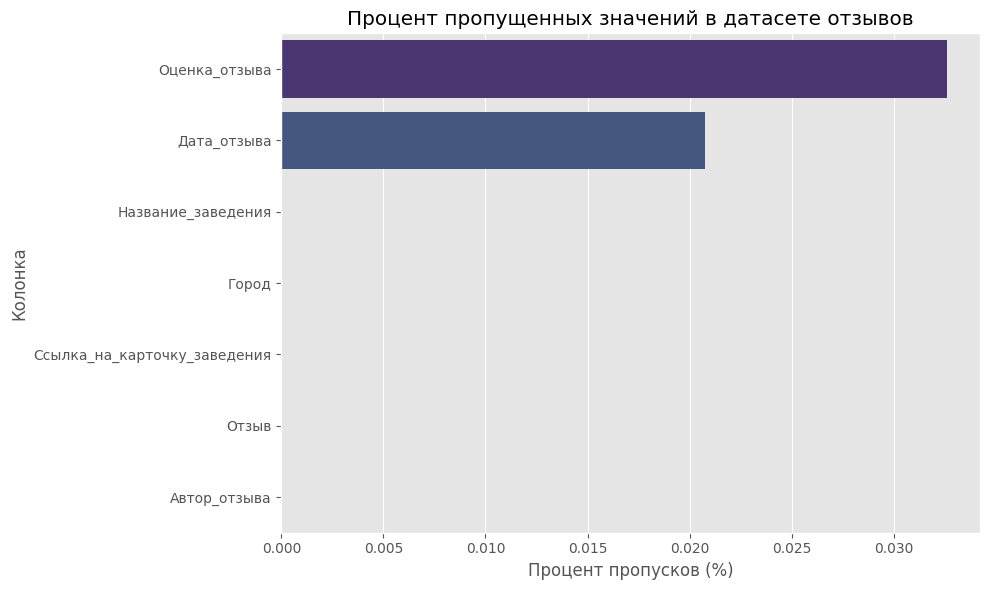

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(y=missing_reviews.index, x=missing_reviews.values, hue = missing_reviews.index, palette='viridis')
plt.title('Процент пропущенных значений в датасете отзывов')
plt.ylabel('Колонка')
plt.xlabel('Процент пропусков (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# ПОСКОЛЬКУ ПРОЦЕНТ ПРОПУСКОВ ОЧЕНЬ МАЛЕНЬКИЙ, ТО МОЖЕМ УДАЛИТЬ СТРОКИ С ПРОПУСКАМИ

1. ОБРАБОТКА ПРОПУСКОВ И ДУБЛИКАТОВ

In [ ]:
df_reviews.dropna(inplace=True)
print(f"Размерность данных df_reviews после удаления строк с пропущенными значениями: {df_reviews.shape}")

Размерность данных df_reviews после удаления строк с пропущенными значениями: (33725, 7)


In [ ]:
# ПОСМОТРИМ НА НАЛИЧИЕ ДУБЛИКАТОВ В ДАННЫХ

duplicates = df_reviews[df_reviews.duplicated(subset=['Автор_отзыва', 'Дата_отзыва'], keep='first')]
print("Число дублирующихся строк:", duplicates.shape[0])
duplicates.head(5)

Число дублирующихся строк: 1793


,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва
3,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Доброго вечера! Заказали два набора по рекомен...,5.0,Лариса Б.,2025-06-11
4,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Заказываю не первый раз и суши и пиццу . Всегд...,5.0,Инна Спичак,2025-09-21
5,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Первый раз решили оформить заказ в Чилли-Вилли...,2.0,Татьяна Фомина,2024-06-21
192,Лаваш,https://yandex.ru/maps/org/lavash/53932429214/,Тюмень,"Сегодня (24.08.2025, 18:30) шаурма совсем не п...",4.0,Елена М.,2025-08-24
193,Лаваш,https://yandex.ru/maps/org/lavash/53932429214/,Тюмень,"Вкусная шаурма! Все понравилось, дружелюбный п...",5.0,Bobr Kurwa,2025-10-17


In [ ]:
# УДАЛЯЕМ ДУБЛИКАТЫ, ОСТАВЛЯЯ ТОЛЬКО ПЕРВОЕ ВХОЖДЕНИЕ
df_reviews = df_reviews.drop_duplicates(subset=['Автор_отзыва', 'Дата_отзыва'], keep='first').copy()
print(f'Размерность датасета после удаления дубликатов: {df_reviews.shape[0]}')

Размерность датасета после удаления дубликатов: 31932


2. ДОБАВЛЕНИЕ ХАРАКТЕРИСТИКИ - ДЛИНА ОТЗЫВА

In [ ]:
# ДОБАВИМ НОВУЮ ХАРАКТЕРИСТИКУ - ДЛИНА ОТЗЫВА

df_reviews['Длина_отзыва'] = df_reviews['Отзыв'].apply(lambda x: len(x))
df_reviews.head()

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва
0,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Доброго вечера! Заказали два набора по рекомен...,5.0,Лариса Б.,2025-06-11,182
1,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Заказываю не первый раз и суши и пиццу . Всегд...,5.0,Инна Спичак,2025-09-21,149
2,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Первый раз решили оформить заказ в Чилли-Вилл...,2.0,Татьяна Фомина,2024-06-21,317
6,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,"Сколько заказываем роллы, всегда быстро и очен...",5.0,Анастасия,2024-09-21,203
7,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,"Прекрасное место, доставка очень быстрая, каче...",5.0,Наталья Макайденко,2025-05-01,212


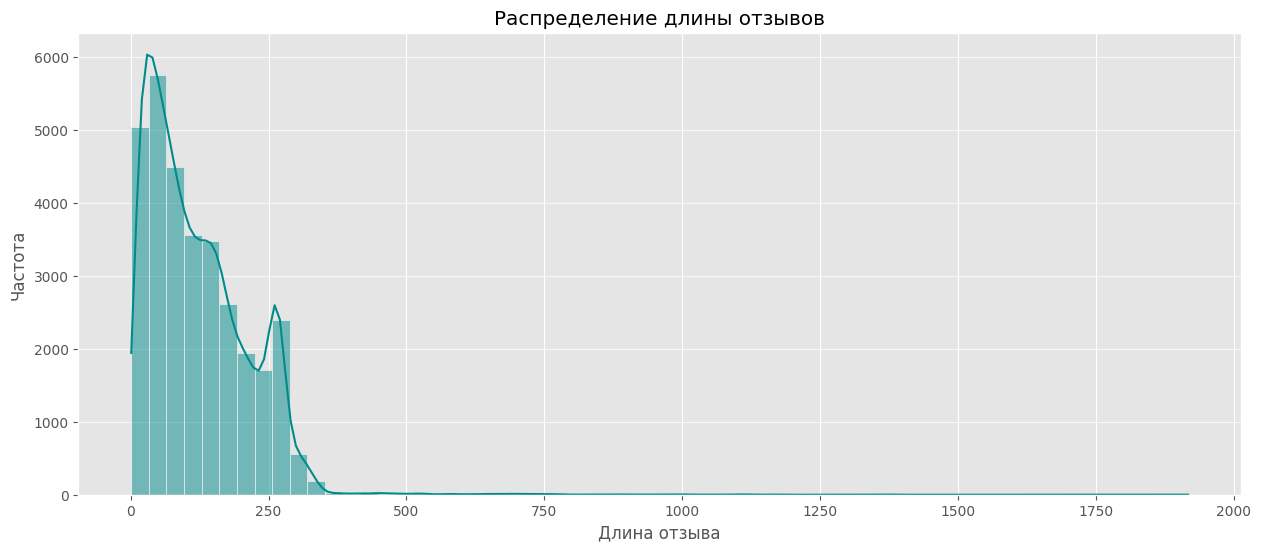

In [ ]:
# РАСПРЕДЕЛЕНИЕ ДЛИНЫ ОТЗЫВОВ

plt.figure(figsize=(15, 6))
sns.histplot(df_reviews['Длина_отзыва'], kde=True, bins=60, color='darkcyan')
plt.title('Распределение длины отзывов')
plt.xlabel('Длина отзыва')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()


Мы видим, что длина отзывов не является стандиртизированной (наблюдается тяжелый правый хвост). Есть как отзывы длины 1, так и отзывы с числом знаков более 2 тысяч. Посмотри, что это за отвызы.

In [ ]:
df_reviews.describe()

,Оценка_отзыва,Длина_отзыва
count,31932.000000,31932.000000
mean,4.359295,122.594733
std,1.241006,94.955187
min,1.000000,1.000000
25%,4.000000,48.000000
50%,5.000000,103.000000
75%,5.000000,178.000000
max,5.000000,1917.000000


In [ ]:
df_reviews[df_reviews['Длина_отзыва'] < 10]

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва
161,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,все супер,5.0,Даша Л.,2025-02-06,9
173,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Любимые!,5.0,Оксана Башмакова,2024-08-20,8
177,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Все круто,5.0,Владислав Хорошилов,2024-01-07,9
289,Лаваш,https://yandex.ru/maps/org/lavash/53932429214/,Тюмень,Вкусно,4.0,Ramin005 and Gaming,2023-07-27,6
291,Лаваш,https://yandex.ru/maps/org/lavash/53932429214/,Тюмень,Вкусно,5.0,Максим Лазарев,2023-10-26,6
...,...,...,...,...,...,...,...,...
20589,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,В центре,5.0,Vladimir,2021-10-29,8
20590,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Класс,5.0,Вася Килан,2021-08-20,5
20591,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Удобно,5.0,Павел Т.,2022-08-04,6
20593,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Еда 🤯🤯🤯,5.0,@liza.polar,2021-10-30,7


In [ ]:
print(f'{df_reviews[df_reviews['Длина_отзыва'] < 10].shape[0] / df_reviews.shape[0] * 100:.2f} % отзывов имеют длину менее 10 символов.')

1.62 % отзывов имеют длину менее 10 символов.


In [ ]:
# ДЛЯ НАШЕГО АНАЛИЗА ТАКИЕ ОТЗЫВЫ БУДУТ МАЛО ИНФОРМАТИВНЫМИ, ПОЭТОМУ УДАЛИМ ИХ
df_reviews = df_reviews[df_reviews['Длина_отзыва'] >= 10]
df_reviews

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва
0,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Доброго вечера! Заказали два набора по рекомен...,5.0,Лариса Б.,2025-06-11,182
1,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Заказываю не первый раз и суши и пиццу . Всегд...,5.0,Инна Спичак,2025-09-21,149
2,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Первый раз решили оформить заказ в Чилли-Вилл...,2.0,Татьяна Фомина,2024-06-21,317
6,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,"Сколько заказываем роллы, всегда быстро и очен...",5.0,Анастасия,2024-09-21,203
7,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,"Прекрасное место, доставка очень быстрая, каче...",5.0,Наталья Макайденко,2025-05-01,212
...,...,...,...,...,...,...,...,...
20586,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Не бк а сборник детей маргиналов,1.0,Евгений Я.,2023-01-24,32
20587,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Отличное место,5.0,Александр,2021-08-28,14
20588,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,Понравилось,5.0,Лиса,2022-10-21,11
20592,Бургер Кинг,https://yandex.ru/maps/org/burger_king/2361670...,Тюмень,заведение класс спрятались там от ментов с сес...,5.0,Валерия Бабаева,2022-05-30,58


In [ ]:
# Создаем колонку с количеством слов
df_reviews['Количество_слов'] = df_reviews['Отзыв'].apply(lambda x: len(str(x).split()))

# Считаем процент отзывов с ≤ 25 слов
процент = df_reviews[df_reviews['Количество_слов'] <= 25].shape[0] / df_reviews.shape[0] * 100
print(f'Процент отзывов с ≤ 25 слов: {процент:.2f}%')

Процент отзывов с ≤ 25 слов: 73.65%


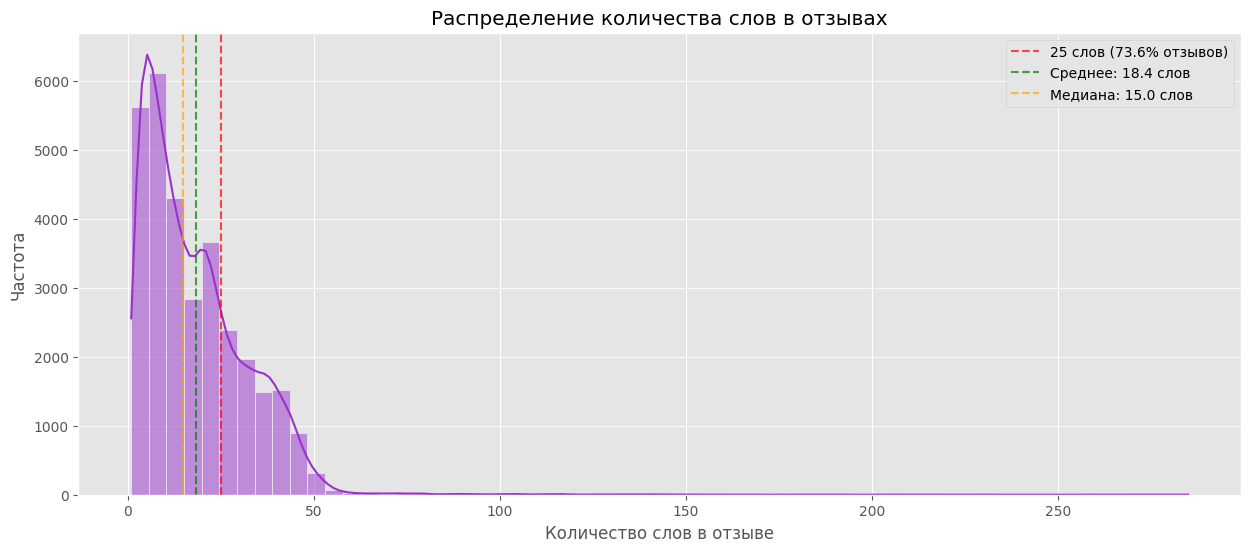

СТАТИСТИКА ПО КОЛИЧЕСТВУ СЛОВ В ОТЗЫВАХ:
Общее количество отзывов: 31415
Минимальное количество слов: 1
Максимальное количество слов: 285
Среднее количество слов: 18.4
Медианное количество слов: 15.0
Отзывов с ≤ 25 слов: 23136 (73.6%)


In [ ]:
# РАСПРЕДЕЛЕНИЕ КОЛИЧЕСТВА СЛОВ В ОТЗЫВАХ
plt.figure(figsize=(15, 6))
sns.histplot(df_reviews['Количество_слов'], kde=True, bins=60, color='darkorchid')
plt.title('Распределение количества слов в отзывах')
plt.xlabel('Количество слов в отзыве')
plt.ylabel('Частота')

# Добавляем вертикальную линию для 25 слов
plt.axvline(x=25, color='red', linestyle='--', alpha=0.7,
            label=f'25 слов ({df_reviews[df_reviews["Количество_слов"] <= 25].shape[0]/df_reviews.shape[0]*100:.1f}% отзывов)')

# Добавляем среднее и медиану
mean_words = df_reviews['Количество_слов'].mean()
median_words = df_reviews['Количество_слов'].median()
plt.axvline(x=mean_words, color='green', linestyle='--', alpha=0.7,
            label=f'Среднее: {mean_words:.1f} слов')
plt.axvline(x=median_words, color='orange', linestyle='--', alpha=0.7,
            label=f'Медиана: {median_words:.1f} слов')

plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.show()

# Выводим статистику
print("СТАТИСТИКА ПО КОЛИЧЕСТВУ СЛОВ В ОТЗЫВАХ:")
print(f"Общее количество отзывов: {df_reviews.shape[0]}")
print(f"Минимальное количество слов: {df_reviews['Количество_слов'].min()}")
print(f"Максимальное количество слов: {df_reviews['Количество_слов'].max()}")
print(f"Среднее количество слов: {df_reviews['Количество_слов'].mean():.1f}")
print(f"Медианное количество слов: {df_reviews['Количество_слов'].median():.1f}")
print(f"Отзывов с ≤ 25 слов: {df_reviews[df_reviews['Количество_слов'] <= 25].shape[0]} ({df_reviews[df_reviews['Количество_слов'] <= 25].shape[0]/df_reviews.shape[0]*100:.1f}%)")

По данным, приведённым выше, видно, что около 73% отзывов содержат не более 25 слов, что отражает привычку пользователей давать короткую оценку без деталей. Рассмотрим самые длинные отзывы детальнее:

In [ ]:
# топ-10 самых длинных отзывов
n = 10
top_longest = df_reviews.nlargest(n, 'Длина_отзыва')[['Название_заведения', 'Город', 'Оценка_отзыва', 'Длина_отзыва', 'Отзыв']]

print(f"Топ-{n} самых длинных отзывов:")
for i, row in top_longest.iterrows():
    print(f"\n{i}. {row['Название_заведения']} ({row['Город']}) - {row['Длина_отзыва']} символов")
    print(f"   Оценка: {row['Оценка_отзыва']}")
    print(f"   Отрывок: {row['Отзыв'][:150]}..." if len(row['Отзыв']) > 100 else f"   {row['Отзыв']}")

Топ-10 самых длинных отзывов:

3. Контора (Тюмень) - 1917 символов
   Оценка: 5.0
   Отрывок: Прибываем в Тюмени в качестве туристов. Соотвественно, расхваленная Тюменская набережная, вечерний променад. Набережная конечно хороша. Но в конце про...

11058. Brew's Lee (Тюмень) - 1826 символов
   Оценка: 5.0
   Отрывок: Brews Lee - Азиатская бироварня в центре Тюмени 😍  📍Адрес: г. Тюмень, ул. Первомайская, 1А 🧧Онлайн-меню: кому хочется выбрать по картинке и ознакомить...

8115. СибирьСибирь (Тюмень) - 1715 символов
   Оценка: 5.0
   Отрывок: С уверенностью могу назвать этот ресторан лучшим гастрономическим опытом в России!  Эстетичный, красивый ресторан с аутентичными дизайнерскими решения...

8117. СибирьСибирь (Тюмень) - 1377 символов
   Оценка: 5.0
   Отрывок: Сибирь-Сибирь входит в ТОП ресторанов Тюмени, это одна из визитных карточек города, как по концепции, так и по отзывам гостей. Мы ходим в этот рестора...

12033. Киоко Изакая (Тюмень) - 1374 символов
   Оценка: 5.0
   Отрывок: Се

Видно, что длинные тексты появляются в основном либо при ярком положительном опыте, либо при сильном неудовлеторении

3. ЧАСТОТНЫЙ АНАЛИЗ

In [ ]:
pip install pymystem3

In [ ]:
import re
import string
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from pymystem3 import Mystem
import nltk
from nltk.corpus import stopwords
from pymystem3 import Mystem

nltk.download('stopwords')
russian_stopwords = stopwords.words('russian')
russian_stopwords.extend(['это', 'весь'])

mystem = Mystem()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    lemmas = mystem.lemmatize(text)
    words = [
        lemma for lemma in lemmas
        if lemma not in russian_stopwords and len(lemma) > 2 and lemma.strip()
    ]

    return ' '.join(words)

df_reviews['Отзыв_очищенный'] = df_reviews['Отзыв'].apply(clean_text)
df_reviews.head(3)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
Installing mystem to /root/.local/bin/mystem from http://download.cdn.yandex.net/mystem/mystem-3.1-linux-64bit.tar.gz


,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва,Количество_слов,Отзыв_очищенный
0,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Доброго вечера! Заказали два набора по рекомен...,5.0,Лариса Б.,2025-06-11,182,27,добрый вечер заказывать набор рекомендация доч...
1,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Заказываю не первый раз и суши и пиццу . Всегд...,5.0,Инна Спичак,2025-09-21,149,30,заказывать первый суша пицца вкусно любимый се...
2,Чилли-Вилли,https://yandex.ru/maps/org/chilli_villi/119166...,Тюмень,Первый раз решили оформить заказ в Чилли-Вилл...,2.0,Татьяна Фомина,2024-06-21,317,51,первый решать оформлять заказ чилль вилли зака...


In [ ]:
text = ' '.join(list(df_reviews['Отзыв_очищенный'])).split()
word_counter = Counter(text)

top_15 = word_counter.most_common(30)
print("Топ-15 слов:")
for word, freq in top_15:
    print(f"{word}: {freq}")

Топ-15 слов:
очень: 13354
вкусный: 9579
вкусно: 7746
место: 5864
хороший: 5689
персонал: 4447
отличный: 4017
заведение: 3979
еда: 3902
обслуживание: 3289
кухня: 3072
блюдо: 3051
понравиться: 3046
заказывать: 3000
приятный: 2737
рекомендовать: 2730
цена: 2579
официант: 2439
быстро: 2264
атмосфера: 2210
большой: 2136
вежливый: 2131
спасибо: 2038
просто: 2001
самый: 1952
заказ: 1937
ресторан: 1928
меню: 1766
кафе: 1743
ролл: 1703


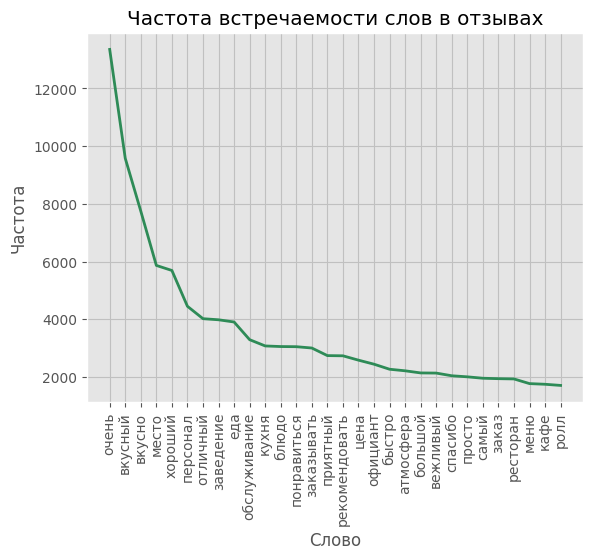

In [ ]:
from nltk.probability import FreqDist
fdist = FreqDist(text)

fdist.plot(30,cumulative=False, color = '#2E8B57')
plt.xlabel('Слово')
plt.ylabel('Частота')
plt.title('Частота встречаемости слов в отзывах')
plt.show()

Анализируя наиболее встречаемые слова в отзывах, можно сделать вывод, что основной фокус отзывов сосредоточен на качестве еды. Однако сервис почти не уступает по важности, слова "персонал", "обслуживание" и "официант" также активно упоминаются, что говорит о значимости человеческого фактора в восприятии заведения.

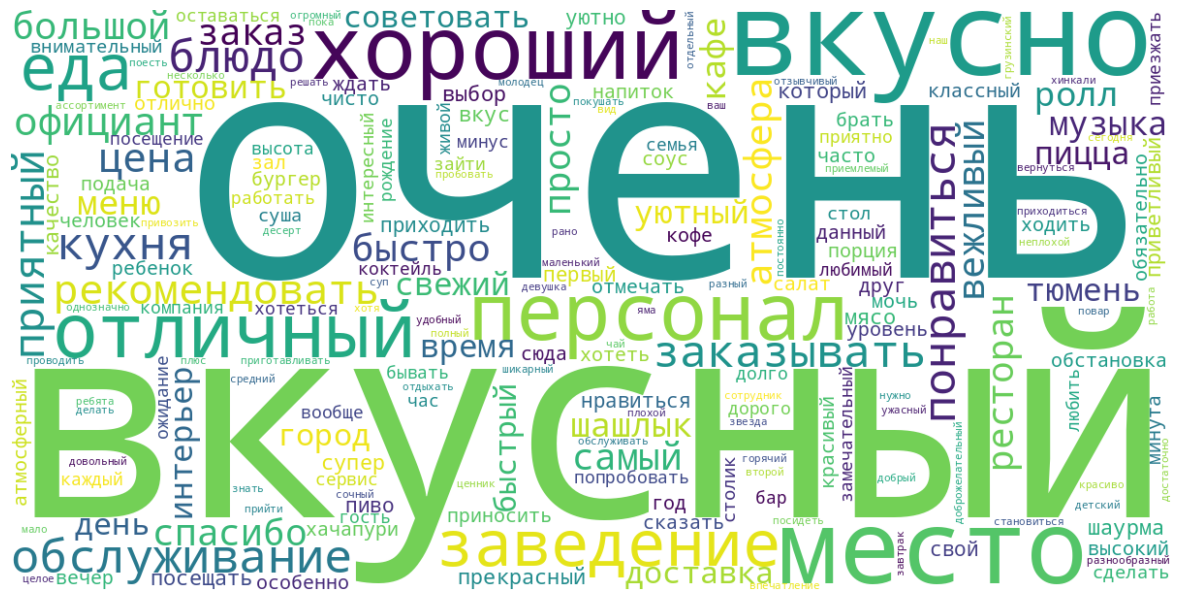

In [ ]:
from wordcloud import WordCloud

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    collocations=False,
).generate(' '.join(text))

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

4. КОЛИЧЕСТВО ОТЗЫВОВ ПО ЗАВЕДЕНИЯМ

In [ ]:
# ПОСМОТРИМ, СКОЛЬКО ВСЕГО ОТЗЫВОВ ПО КАЖДОМУ ЗАВЕДЕНИЮ
df_reviews.groupby(['Название_заведения', 'Ссылка_на_карточку_заведения'])['Отзыв'].count().sort_values(ascending=False)

,,Отзыв
Название_заведения,Ссылка_на_карточку_заведения,
Чико,https://yandex.ru/maps/org/chiko/14553329539/,596
Ржавый ДЕД,https://yandex.ru/maps/org/rzhavy_ded/19171203497/,596
Восточная долина,https://yandex.ru/maps/org/vostochnaya_dolina/1889094165/,593
TomYumBar,https://yandex.ru/maps/org/tomyumbar/186278640224/,592
Бухара,https://yandex.ru/maps/org/bukhara/1187205255/,590
...,...,...
Лаванда,https://yandex.ru/maps/org/lavanda/104441558124/,2
Мираж,https://yandex.ru/maps/org/mirazh/151621361798/,2
Shaurmaker,https://yandex.ru/maps/org/shaurmaker/164772034046/,1


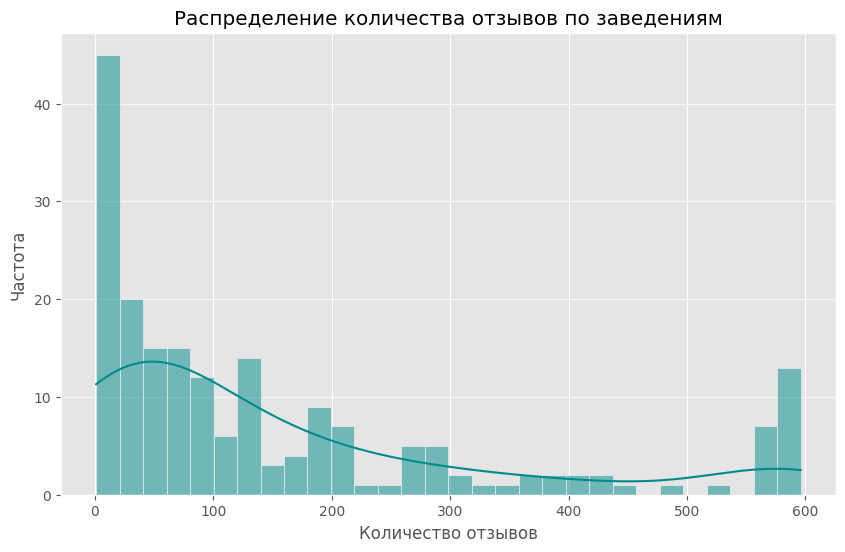

In [ ]:
review_counts = df_reviews.groupby(['Название_заведения', 'Ссылка_на_карточку_заведения'])['Отзыв'].count()

plt.figure(figsize=(10, 6))
sns.histplot(review_counts, kde=True, bins=30, color='darkcyan')
plt.title('Распределение количества отзывов по заведениям')
plt.xlabel('Количество отзывов')
plt.ylabel('Частота')
plt.grid(axis='y', alpha=0.75)
plt.show()

Распределение отзывов по заведениям демонстирует ярко выраженную неравномерность. Большая часть заведений собирает крайне мало отзывов, тогда как популярные "локальные лидеры" привлекают наибольшее внимание клиентов.

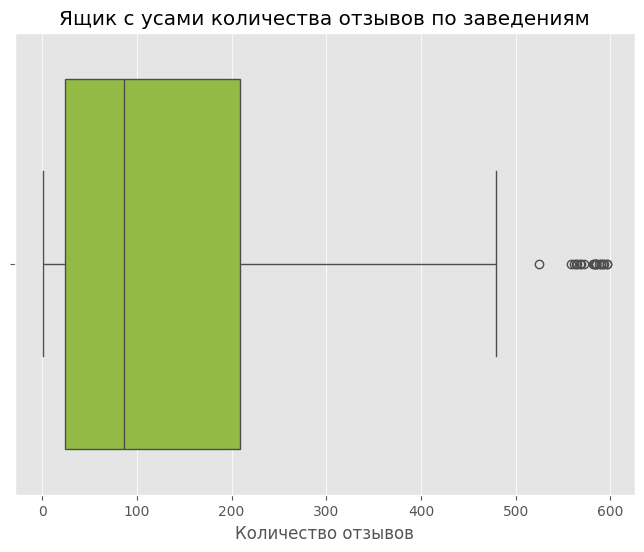

24.0 209.0 185.0


In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(x=review_counts, color='#9ACD32')
plt.title('Ящик с усами количества отзывов по заведениям')
plt.xlabel('Количество отзывов')
plt.grid(axis='x', alpha=0.75)
plt.show()

Q1 = np.quantile(review_counts, 0.25)
Q3 = np.quantile(review_counts, 0.75)
IQR = Q3 - Q1

print(Q1, Q3, IQR)

Видим, что есть популярные заведения, где количество отзывов превышает 400, и есть заведения, где количество отзывов меньше 10. То есть количество отзывов по заведениям неравномерно и сильно отличается.

Посмотрим сколько таких заведений

In [ ]:
low = 10
upper = 400

print(f'Количество заведений с числом отзывов менее {low}: {(review_counts < low).sum()} ({(review_counts < low).sum()/len(review_counts)*100:.2f}%)')
print(f'Количество заведений с числом отзывов более {upper}: {(review_counts > upper).sum()} ({(review_counts > upper).sum()/len(review_counts)*100:.2f}%)')

Количество заведений с числом отзывов менее 10: 24 (12.18%)
Количество заведений с числом отзывов более 400: 27 (13.71%)


В силу того, что в данных присутствуют заведения с экстремальным числов отзывов, то мы случайно у таких заведений оставим 30 отзывов. Это позволит ускорить обработку данных, а также сбалансировать датасет для дальнейшего анализа.

In [ ]:
# Группируем по названию заведения и оставляем не более 30 случайных отзывов
df_reviews_cut = df_reviews.groupby(['Название_заведения', 'Ссылка_на_карточку_заведения']).apply(lambda x: x.sample(min(len(x), 30), random_state=42)).reset_index(drop=True)

print("Исходное количество отзывов:", len(df_reviews))
print("Количество отзывов в новом датасете:", len(df_reviews_cut))

Исходное количество отзывов: 31415
Количество отзывов в новом датасете: 4952


/tmp/ipython-input-2102175595.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_reviews_cut = df_reviews.groupby(['Название_заведения', 'Ссылка_на_карточку_заведения']).apply(lambda x: x.sample(min(len(x), 30), random_state=42)).reset_index(drop=True)


In [ ]:
orgs_count = df_reviews_cut[['Название_заведения','Ссылка_на_карточку_заведения']].value_counts()
print(orgs_count.shape)
names = [name for name, url in orgs_count[orgs_count > 10].index]
len(names)

(197,)


170

In [ ]:
# ТАКЖЕ ИСКЛЮЧИМ ЗАВЕДЕНИЯ, У КОТОРЫХ КОЛИЧЕСТВО ОТЗЫВОВ МЕНЬШЕ 10
df_reviews_cut['ресайз'] = df_reviews_cut.groupby(['Название_заведения', 'Ссылка_на_карточку_заведения']).transform('size')

df_filtered = df_reviews_cut[df_reviews_cut['ресайз'] > 10].drop(columns=['ресайз'])
df_filtered[['Название_заведения', 'Ссылка_на_карточку_заведения']].value_counts()

,,count
Название_заведения,Ссылка_на_карточку_заведения,
Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,30
Brew's Lee,https://yandex.ru/maps/org/brew_s_lee/228165355003/,30
Duner от мясника,https://yandex.ru/maps/org/duner_ot_myasnika/215933548814/,30
Brooklyn Bowl,https://yandex.ru/maps/org/brooklyn_bowl/160611052163/,30
Brunch,https://yandex.ru/maps/org/brunch/145824888608/,30
...,...,...
Плов хауз,https://yandex.ru/maps/org/plov_khauz/175953244714/,14
Mangal,https://yandex.ru/maps/org/mangal/28041120798/,13
ЧебурекМи,https://yandex.ru/maps/org/cheburekmi/167278678220/,13


In [ ]:
# СОХРАНЯЕМ ПРЕДОБРАБОТАННЫЕ ДАННЫЕ
df_filtered.to_csv('data_reviews_filtered.csv', index=False, encoding='utf-8')

In [ ]:
df_filtered.head() # ИТОГОВЫЙ ОТФИЛЬТРОВАННЫЙ ДАТАСЕТ

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва,Количество_слов,Отзыв_очищенный
0,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Заходил на бизнес-ланч. Все понравилось. Был в...,5.0,Юрий,2019-07-19,70,9,заходить бизнес ланч понравиться вкусный грибн...
1,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Понравилось, был до ремонта и после, сейчас од...",5.0,Александр Парыгин,2023-11-24,67,9,понравиться ремонт однозначно атмосферный
2,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"После ремонта очень красиво, свежо, понравилас...",5.0,Айслу,2023-01-02,88,13,ремонт очень красиво свежо понравиться атмосфе...
3,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Все отлично, Лучший Ведущий",5.0,Кирилл Шадеркин,2020-03-28,27,4,отлично хороший ведущий
4,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Очень понравился новый интерьер клуба. Как все...,5.0,Денис С.,2023-02-10,258,38,очень понравиться новый интерьер клуб отличный...


In [ ]:
df_filtered.shape # РАЗМЕРНОСТЬ ИТОГОВОГО ДАТАСЕТА

(4809, 10)

5. ДОБАВЛЕНИЕ НОВОЙ ХАРАКТЕРИСТИКИ - ТОНАЛЬНОСТЬ ОТЗЫВА

Анализ с использованием API GigaChat доступен по сслыке: https://colab.research.google.com/drive/1tvgVMP-HenpD5WlVWr5hVbxnpwxP5mX4?usp=sharing

In [ ]:
# ПОДГРУЖАЕМ ДАТАСЕТ, СОЗДАННЫЙ ПОСЛЕ ПРЕДОБРАБОТКИ API GIGACHAT
df_reviews_ton = pd.read_csv('analyzed_output.csv')
df_reviews_ton.head()

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва,Тональность,Тематика
0,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Заходил на бизнес-ланч. Все понравилось. Был в...,5.0,Юрий,2019-07-19,70,позитивный,еда
1,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Понравилось, был до ремонта и после, сейчас од...",5.0,Александр Парыгин,2023-11-24,67,позитивный,атмосфера
2,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"После ремонта очень красиво, свежо, понравилас...",5.0,Айслу,2023-01-02,88,позитивный,ремонт
3,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Все отлично, Лучший Ведущий",5.0,Кирилл Шадеркин,2020-03-28,27,позитивный,ведущий
4,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Очень понравился новый интерьер клуба. Как все...,5.0,Денис С.,2023-02-10,258,позитивный,клуб


In [ ]:
df_reviews_ton['Тональность'].value_counts()

,count
Тональность,
позитивный,3518
негативный,884
нейтральный,385
Ошибка API,19
ироничный,1
ностальгическая,1
К сожалению,1


Видим, что в результате обработки api выдал ошибки, а также отличный тип отзыва от нейтральный/позитивный/негативный.

Поскольку в сравнении с размерностью общего датасета такие отзывы составлют небольшую часть, то просто удалим такие строки.

In [ ]:
df_reviews_ton = df_reviews_ton[df_reviews_ton['Тональность'].apply(lambda x: True if x in ['позитивный', 'негативный', 'нейтральный'] else False)]

In [ ]:
df_reviews_ton.shape # размерность данных после удаления отзывов с ошибками по тональности

(4787, 10)

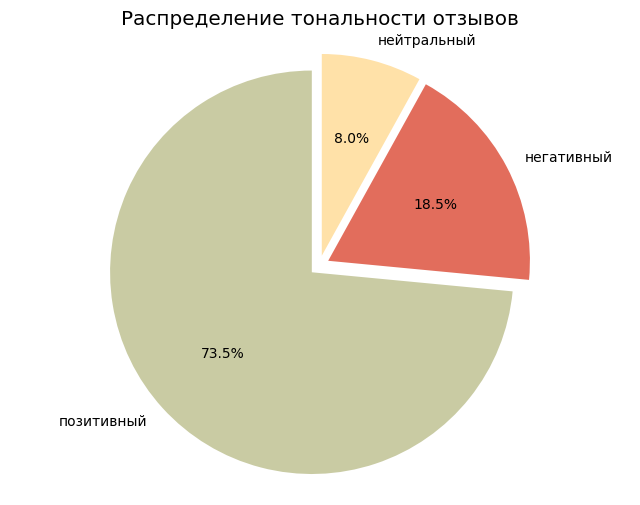

In [ ]:
ton = df_reviews_ton['Тональность'].value_counts()
plt.figure(figsize=(8, 6))
plt.pie(
    ton.values,
    labels=ton.index,
    autopct='%1.1f%%',
    startangle=90,
    colors= ['#c9cba3', '#e26d5c', '#ffe1a8'],
    explode=(0.05, 0.05, 0.05)
)

plt.title('Распределение тональности отзывов')
plt.axis('equal')
plt.show()

Данный график свидетельствует о том, что подавляющее число отзывов по завдениям - позитиные. Это говорит о том, что большинство посетителей заведений получают положительный опыт, которым они готовы поделиться

6. АНАЛИЗ ТОНАЛЬНОСТИ

In [ ]:
# ОБЛАКА СЛОВ ПО ТОНАЛЬНОСТИ

common_cols = [
    'Название_заведения', 'Ссылка_на_карточку_заведения', 'Город', 'Отзыв',
    'Оценка_отзыва', 'Автор_отзыва', 'Дата_отзыва', 'Длина_отзыва'
]

# присоединим колонку с лемматизированным отзывом
df_final = df_reviews_ton.merge(
    df_filtered[common_cols + ['Отзыв_очищенный']],
    on=common_cols,
    how='left'
)
print(df_final.shape)
df_final.head(3)

(4787, 11)


,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва,Тональность,Тематика,Отзыв_очищенный
0,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Заходил на бизнес-ланч. Все понравилось. Был в...,5.0,Юрий,2019-07-19,70,позитивный,еда,заходить бизнес ланч понравиться вкусный грибн...
1,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Понравилось, был до ремонта и после, сейчас од...",5.0,Александр Парыгин,2023-11-24,67,позитивный,атмосфера,понравиться ремонт однозначно атмосферный
2,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"После ремонта очень красиво, свежо, понравилас...",5.0,Айслу,2023-01-02,88,позитивный,ремонт,ремонт очень красиво свежо понравиться атмосфе...


In [ ]:
# создадим массив шумовых слов

noise_words = ['заказ', 'заказывать', 'доставка','доставлять', 'еда',
    'заведение', 'ролл', 'место', 'который']

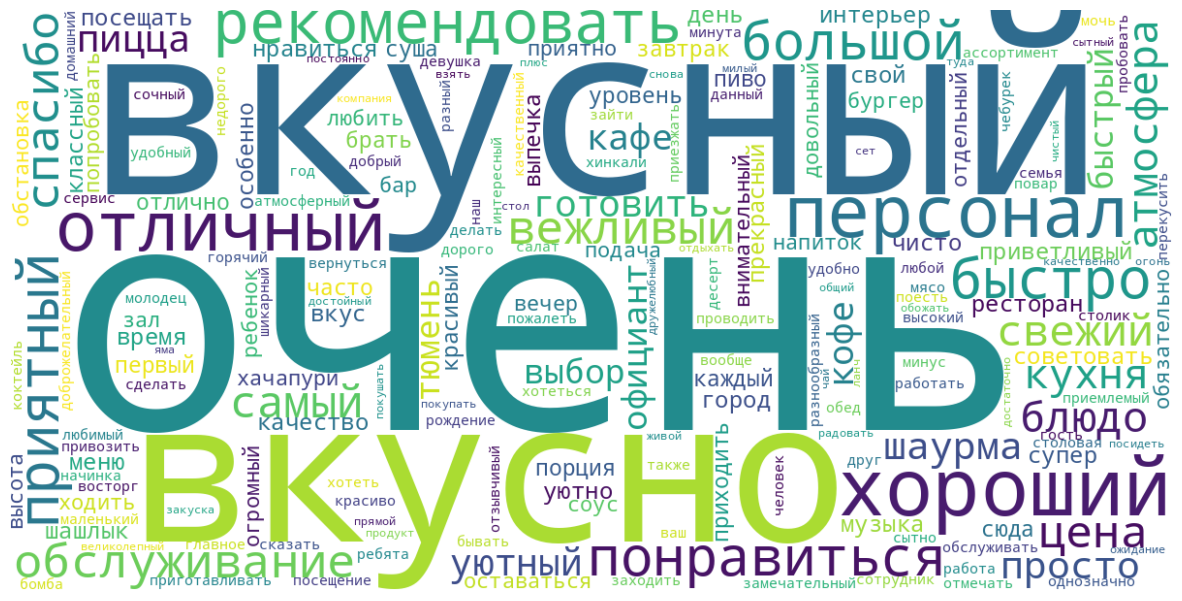

In [ ]:
# ОБЛАКО СЛОВ ДЛЯ ПОЗИТИВНЫЙ ОТЗЫВОВ

from wordcloud import WordCloud
text_positiv = ' '.join(list(df_final[df_final['Тональность'] == 'позитивный']['Отзыв_очищенный']))
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    collocations=False,
).generate(' '.join([i for i in text_positiv.split() if i not in noise_words]))

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

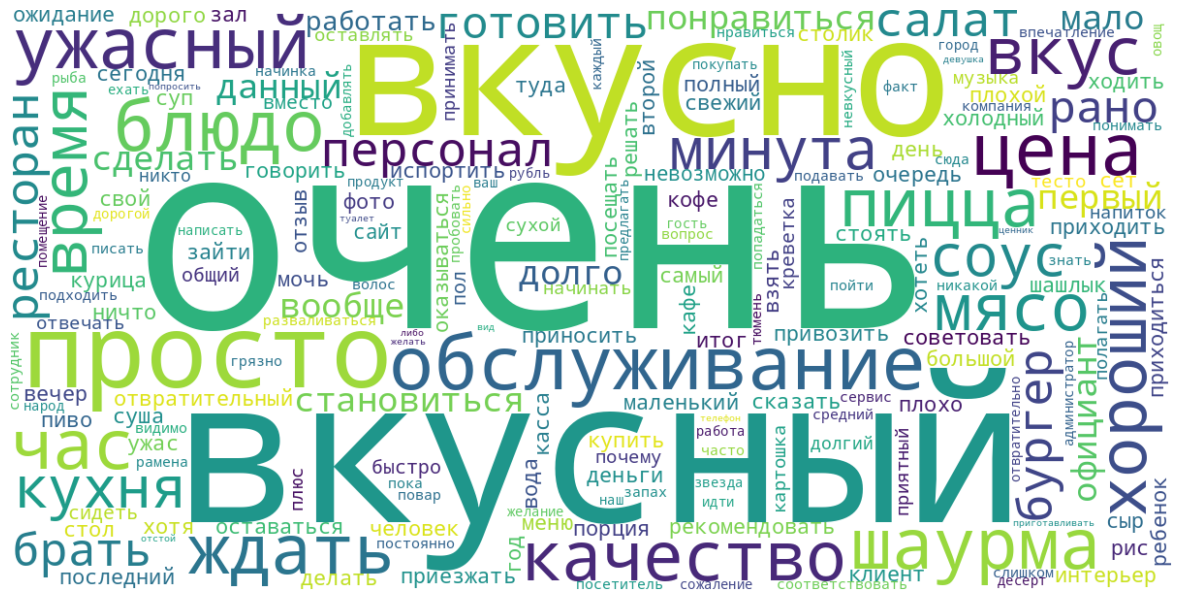

In [ ]:
# ОБЛАКО СЛОВ ДЛЯ НЕГАТИВНЫХ ОТЗЫВОВ

text_negativ = ' '.join(list(df_final[df_final['Тональность'] == 'негативный']['Отзыв_очищенный']))
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    collocations=False,).generate(' '.join([i for i in text_negativ.split() if i not in noise_words]))

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

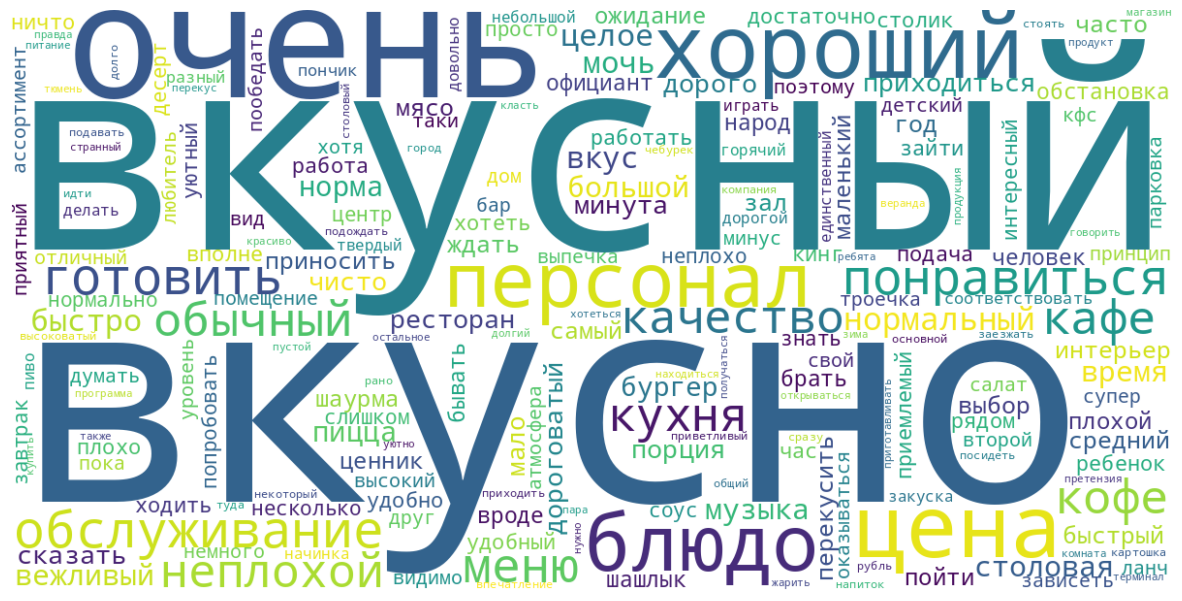

In [ ]:
# ОБЛАКО СЛОВ ДЛЯ НЕЙТРАЛЬНЫХ ОТЗЫВОВ

text_neitral = ' '.join(list(df_final[df_final['Тональность'] == 'нейтральный']['Отзыв_очищенный']))
wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color='white',
    colormap='viridis',
    collocations=False,
).generate(' '.join([i for i in text_neitral.split() if i not in noise_words]))

plt.figure(figsize=(15, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [ ]:
df_final.to_csv('df_final.csv', index=False, encoding='utf-8') # сохраним предобработанный датасет

ПРОАНАЛИЗИРУЕМ ТЕМАТИКУ ОТЗЫВОВ

In [ ]:
topic_counts = df_final['Тематика'].value_counts().reset_index()
topic_counts.columns = ['Тематика', 'Количество']
topic_counts

,Тематика,Количество
0,еда,2751
1,обслуживание,1126
2,доставка,221
3,продукт,124
4,кафе,68
...,...,...
132,безопасность,1
133,кальян,1
134,шум и беспорядок,1
135,посещение (досуг),1


Посмотрим на топ популярных тематик в отзывах

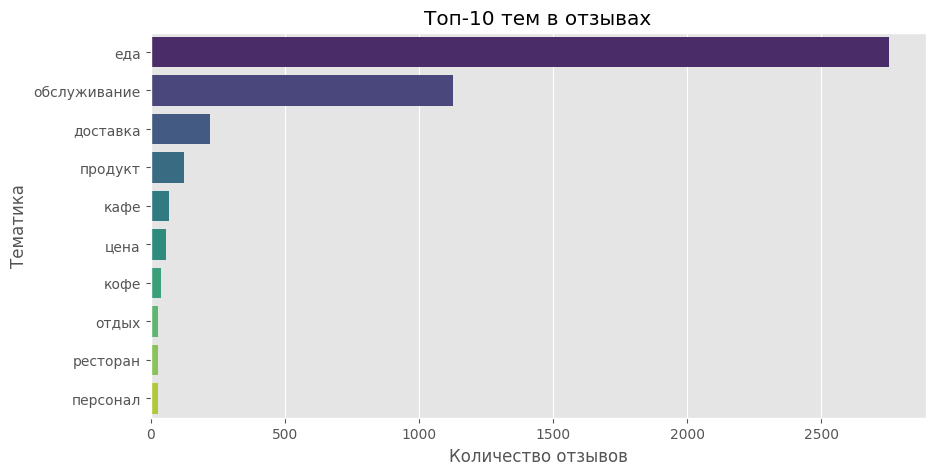

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=topic_counts.head(10), x='Количество', y='Тематика', hue = 'Тематика', palette='viridis')
plt.title('Топ-10 тем в отзывах')
plt.xlabel('Количество отзывов')
plt.ylabel('Тематика')
plt.show()

График показывает, что основынми темами в отзывах являются еда и обсуживание - они лидируют с уверенным отрывом по количеству упоминаний. Далее следуют доставка, продукт и кафе, что указывает на важность качества пищи, сервиса и удобства для клиентов. Остальные темы встречаются реже, что говорит о сфокусированности обратной связи пользователей на ключевых аспектах работы заведений


Посмотрим на средний рейтинг в наиболее популярных категориях

In [ ]:
avg_rating_by_topic = df_final.groupby('Тематика')['Оценка_отзыва'].agg(['mean', 'count']).sort_values(by = 'count', ascending=False).reset_index()
avg_rating_by_topic = avg_rating_by_topic.head(5)
avg_rating_by_topic

,Тематика,mean,count
0,еда,4.490367,2751
1,обслуживание,4.111901,1126
2,доставка,3.656109,221
3,продукт,3.556452,124
4,кафе,4.705882,68


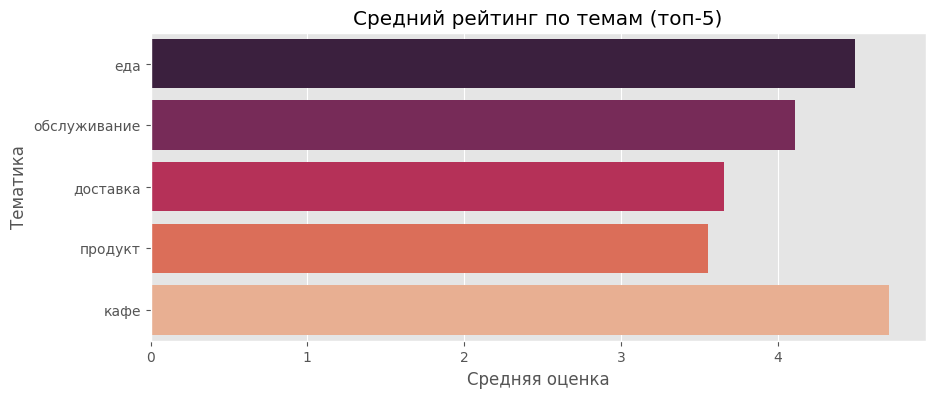

In [ ]:
plt.figure(figsize=(10, 4))
sns.barplot(data = avg_rating_by_topic,
            x='mean', y='Тематика', hue = 'Тематика', palette='rocket')
plt.title('Средний рейтинг по темам (топ-5)')
plt.xlabel('Средняя оценка')
plt.ylabel('Тематика')
plt.show()

Все средние оценки находятся в диапазоне от ~3.5 до 4.7. Лидером является тема "кафе" со средней оценкой 4.7. Однако важно помнить, что по этой теме всего 68 отзывов (наименьшее количество в топ-5). Такой высокий рейтинг при малом количестве отзывов может быть менее статистически устойчивым.

Наиболее значимая тема "еда" (2751 отзыва) имеет высокий рейтинг - 4.5, что говорит о стабильно высоком качестве и удовлетворённости по главному для клиентов критерию

"Обслуживание" (1126 отзывов) также получает высокую оценку - 4.11.

"Доставка" и "продукт" имеют более низкие оценки (3.66 и 3.56 соответственно). Их можно рассматривать как потенциальные точки улучшения

Наконец, оценим полярность отзывов, то есть, посмотрим, какая средняя тональность в часто встречающихся темах отзывов.

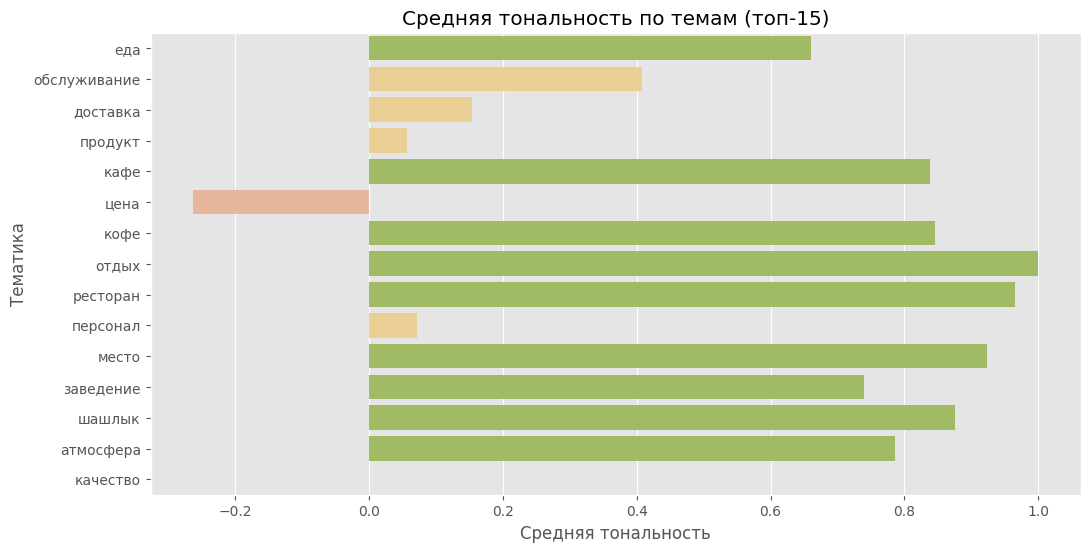

In [ ]:
df_final['Тональность_число'] = df_final['Тональность'].map({'позитивный': 1, 'негативный': -1, 'нейтральный': 0})
avg_sent_by_topic = df_final.groupby('Тематика')['Тональность_число'].agg(['mean', 'count']).reset_index().sort_values(by = 'count', ascending = False).head(15).reset_index(drop = True)
avg_sent_by_topic

def get_color(val):
    if val < 0:
        return '#f3b391'
    elif val <= 0.5:
        return '#f7d486'
    else:
        return '#a7c957'

colors = [get_color(val) for val in avg_sent_by_topic['mean']]

plt.figure(figsize=(12, 6))
sns.barplot(data = avg_sent_by_topic,
            x='mean', y='Тематика', hue = 'Тематика', palette=colors)
plt.title('Средняя тональность по темам (топ-15)')
plt.xlabel('Средняя тональность')
plt.ylabel('Тематика')
plt.show()

Во всех ключевых аспектах клиенты выражают высокую удовлетворённость (тональность близка к 1.0). Единственное исключение - "цена", где средняя тональность отрицательная, что указывает на восприятие заведений как дорогих. В целом, можно сказать что качество и сервис оправдывают ожидания, но ценовая политика вызывает у людей недовольство

##### АНАЛИЗ ДАТАСЕТА С ЗАВЕДЕНИЯМИ

In [ ]:
print("Информация о датасете с заведениями")
print(df_orgs.info())

Информация о датасете с заведениями
<class 'pandas.core.frame.DataFrame'>
Index: 1801 entries, 0 to 200
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Название_заведения            1801 non-null   object 
 1   Ссылка_на_карточку_заведения  1801 non-null   object 
 2   Теги                          1801 non-null   object 
 3   Тип_заведения                 846 non-null    object 
 4   Особенности_заведения         931 non-null    object 
 5   Кухня                         1402 non-null   object 
 6   Средний_чек                   1312 non-null   float64
 7   Рейтинг                       1783 non-null   float64
 8   Описание                      1130 non-null   object 
 9   Адрес                         1801 non-null   object 
 10  Город                         1801 non-null   object 
 11  Телефон                       1693 non-null   object 
 12  Сайт                          11

In [ ]:
# УДАЛЯЕМ ДУБЛИКАТЫ И ПРОПУСКИ (в колонках, где их мало)

df_orgs = df_orgs.dropna(subset=['Рейтинг', 'Количество_оценок'])
print(f"Размерность данных df_reviews после удаления строк с пропущенными значениями: {df_orgs.shape}")

df_orgs.drop_duplicates(keep='first')
print(f"Размерность данных df_reviews после удаления дубликатов: {df_orgs.shape}")  # видим, что дубликатов нет

Размерность данных df_reviews после удаления строк с пропущенными значениями: (1763, 16)
Размерность данных df_reviews после удаления дубликатов: (1763, 16)


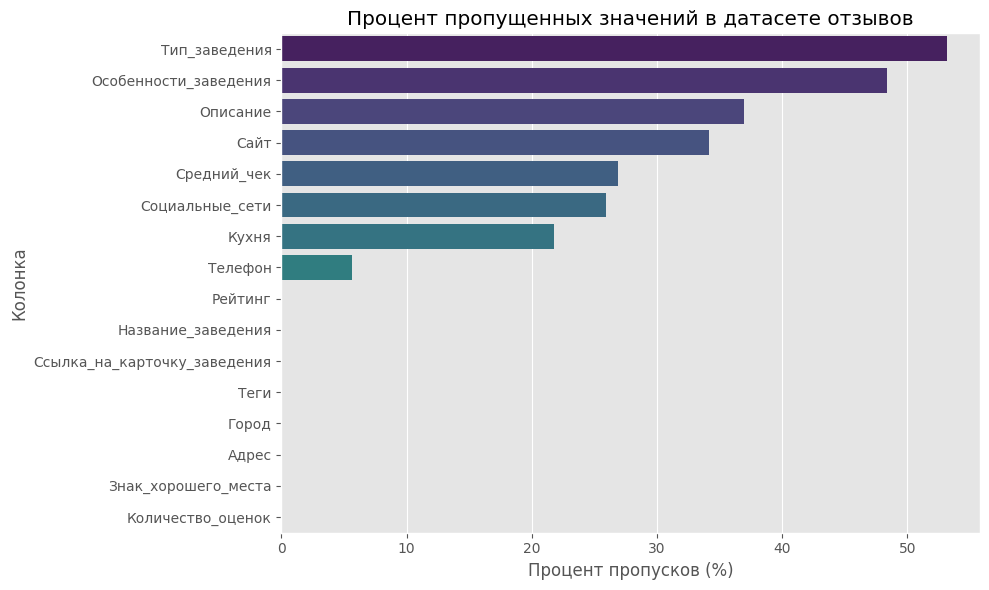

In [ ]:
missing_reviews = df_orgs.isna().mean().sort_values(ascending=False) * 100
plt.figure(figsize=(10, 6))
sns.barplot(y=missing_reviews.index, x=missing_reviews.values, hue = missing_reviews.index, palette='viridis')
plt.title('Процент пропущенных значений в датасете отзывов')
plt.ylabel('Колонка')
plt.xlabel('Процент пропусков (%)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. ЗАПОЛНИМ ПРОПУСКИ В КОЛОНКЕ СРЕДНИЙ ЧЕК НА ОСНОВЕ СХОЖИХ ХАРАКТЕРИСТИК ЗАВЕДЕНИЯ

In [ ]:
# ЗАПОЛНИМ СРЕДНИЙ ЧЕК

# агрегируем по заведениям, поскольку у разных филиалов по городам плюс минус одинаковые цены
grouped = df_orgs.groupby('Название_заведения').agg(
    Средний_рейтинг=('Рейтинг', 'mean'),
    Кол_отзывов=('Рейтинг', 'count'),
    Средний_чек_известный=('Средний_чек', 'mean')
).reset_index()

# заполнение медианным чеков по рейтингу
grouped['Рейтинг_бин'] = pd.cut(grouped['Средний_рейтинг'], bins=[0, 3.5, 4.0, 4.5, 5.0], labels=['низкий', 'средний', 'высокий', 'премиум'])
median_check_by_bin = grouped.groupby('Рейтинг_бин')['Средний_чек_известный'].median()

# Функция для заполнения пропусков в исходном датафрейме
def fill_check(row, ref_df, medians):
    if pd.notna(row['Средний_чек']):
        return row['Средний_чек']

    place_data = ref_df[ref_df['Название_заведения'] == row['Название_заведения']]
    if place_data.empty:
        return np.nan
    bin_label = place_data.iloc[0]['Рейтинг_бин']
    return medians.get(bin_label, np.nan)

df_orgs['Средний_чек'] = df_orgs.apply(lambda row: fill_check(row, grouped, median_check_by_bin), axis=1)

/tmp/ipython-input-3925683104.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_check_by_bin = grouped.groupby('Рейтинг_бин')['Средний_чек_известный'].median()


In [ ]:
# ПРОВЕРКА
df_orgs['Средний_чек'].isna().mean() # больше пропусков в колонке со средним чеком нет

np.float64(0.0)

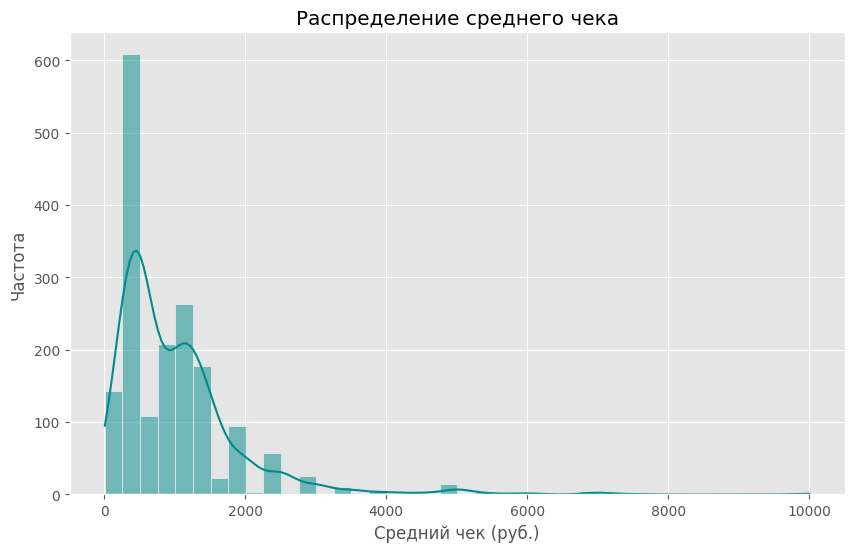

In [ ]:
# ГРАФИК 1 - ГИСТОГРАММА СРЕДНИЙ ЧЕК
plt.figure(figsize=(10, 6))
sns.histplot(data=df_orgs, x='Средний_чек', bins = 40, kde=True, color = 'darkcyan')
plt.title('Распределение среднего чека')
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()


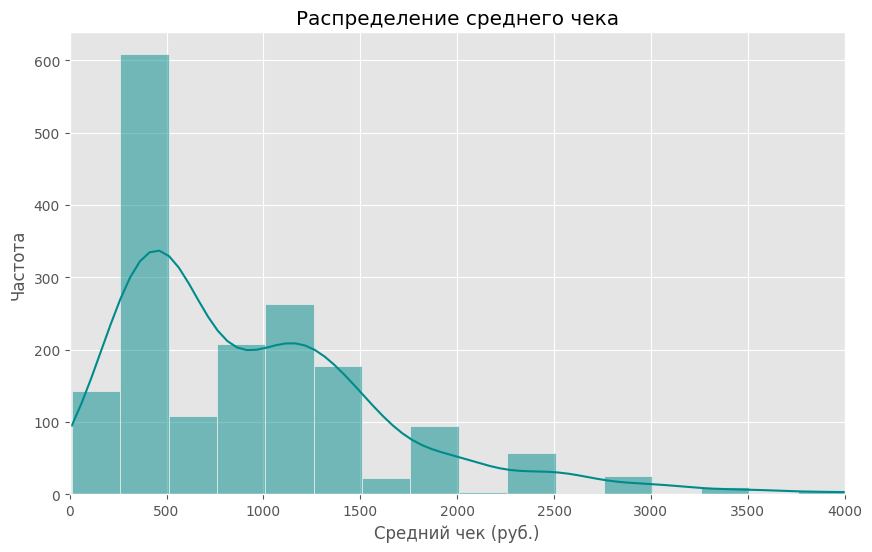

In [ ]:
# ГРАФИК 1.1 - ГИСТОГРАММА СРЕДНИЙ ЧЕК с лимитами по x
plt.figure(figsize=(10, 6))
sns.histplot(data=df_orgs, x='Средний_чек', bins = 40, kde=True, color = 'darkcyan')
plt.xlim(0, 4000)
plt.title('Распределение среднего чека')
plt.xlabel('Средний чек (руб.)')
plt.ylabel('Частота')
plt.grid(True)
plt.show()

График показывает, что подавляющее большинство посетителей тратят до 1000 рублей за визит, и что чем выше сумма чека, тем реже он встречается. Так, после 1500 рублей фиксируется резкое падание кривой, чеки выше 3500-4000 руб. встречаются крайне редко.

Можно сделать вывод, что большинство заведений ориентированы на массового потребителя с бюджетом до 1500-2000 рублей.

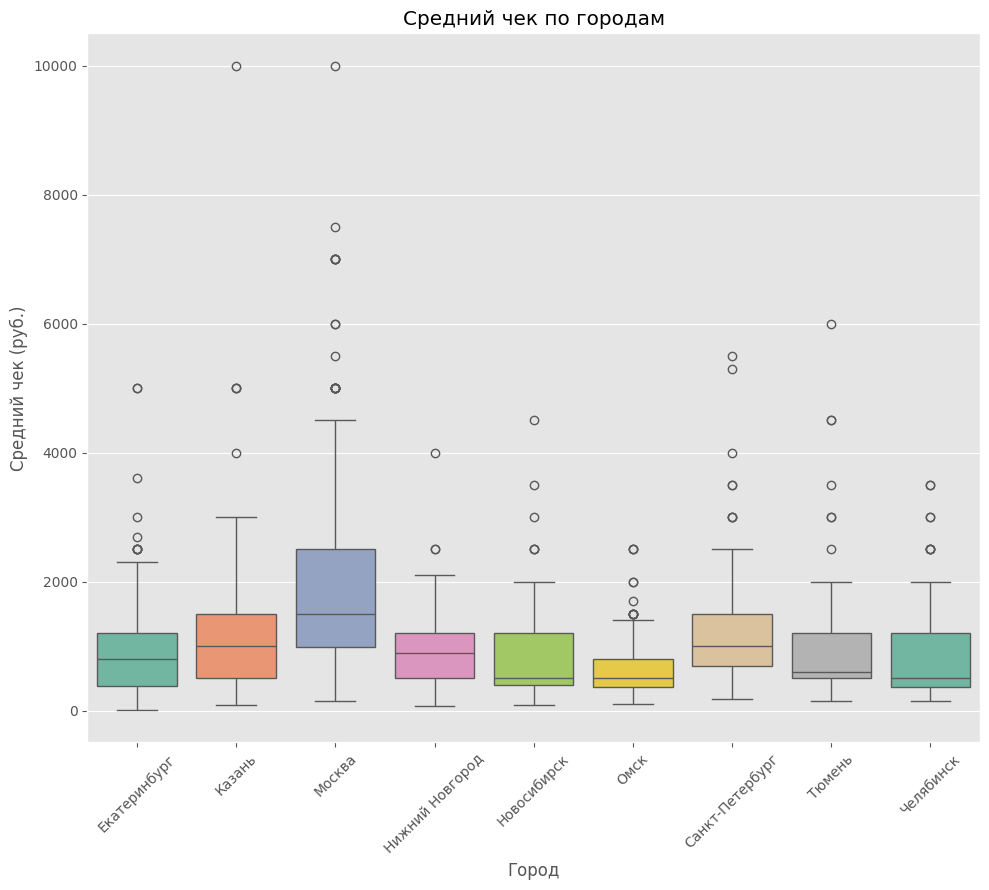

In [ ]:
# ГРАФИК 2 - СРЕДНИЙ ЧЕК - БОКС ПЛОТ ПО ГОРОДАМ
plt.figure(figsize=(10, 9))
sns.boxplot(data=df_orgs, x='Город', y='Средний_чек', hue = 'Город', palette='Set2')
plt.title('Средний чек по городам')
plt.xlabel('Город')
plt.ylabel('Средний чек (руб.)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Считатем более точные значения для анализа
print("Перцентили среднего чека по городам:")

stats = df_orgs.groupby('Город')['Средний_чек'].describe(percentiles=[.25, .5, .75,])
stats = stats.round(0).astype(int)
stats.columns = ['N', 'Средний чек', 'Стд.откл.', 'min', '25%', '50%', '75%', 'масимальный выброс']
stats

Перцентили среднего чека по городам:


,N,Средний чек,Стд.откл.,min,25%,50%,75%,масимальный выброс
Город,,,,,,,,
Екатеринбург,200,949,760,11,380,795,1200,5000
Казань,185,1149,1082,90,500,1000,1500,10000
Москва,195,2042,1653,150,988,1500,2500,10000
Нижний Новгород,195,916,537,70,500,900,1200,4000
Новосибирск,198,807,633,90,400,500,1200,4500
Омск,198,640,447,100,375,500,800,2500
Санкт-Петербург,195,1215,815,180,700,1000,1500,5500
Тюмень,197,903,759,150,500,600,1200,6000
Челябинск,200,806,618,150,375,500,1200,3500


Наиболее высокие расходы посетителей наблюдаются в Москве: медиана составляет около 1500 рублей, а верхний квартиль достигает 2500 рублей. Это объясняется высоким уровнем цен в регионе.

Санкт-Петербург и Казань формируют промежуточную группу: медиана чека в обоих городах около 1000 рублей.

В свою очередь, такие города, как Нижний Новгород, Екатеринбург, Тюмень, Новосибирск, Челябинск и Омск характеризируются более низким уровнем цен: медиана чаще находится в диапазоне 500-900 рублей. Омск выделяется самым низким средним чеком и относительно небольшим разбросом, что отражает преимущественно бюджетный формат заведений. Напротив, Екатеринбург и Тюмень демонстрируют более широкий диапазон расходов: несмотря на сопоставимые медианы, оба города имеют высокие выбросы.

В целом, распределение чеков показывает, что структура рынка общепита сильно зависит от уровня доходов населения и насыщенности премиальными заведениями. Москва и в меньшей степени Санкт-Петербург и Казань имеют более дорогой и сегментированный рынок питания, тогда как большинство регионов формируют устойчивый спрос в массовом, относительно недорогом сегменте. Такой контраст подчёркивает региональную специфику потребительского поведения и различия в ценовых стратегиях заведений общепита.

In [ ]:
# ПОСМОТРИМ НА ЗАВДЕЕНИЯ, КОТОРЫЕ ЯВЛЯЮТСЯ ВЫБРОСАМИ ПО СРЕДНЕМУ ЧЕКУ
def find_outliers_by_city(data):
    Q1 = data['Средний_чек'].quantile(0.25)
    Q3 = data['Средний_чек'].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return data[(data['Средний_чек'] < lower_bound) | (data['Средний_чек'] > upper_bound)]
outliers = df_orgs.groupby('Город').apply(find_outliers_by_city).reset_index(drop=True)
outliers

/tmp/ipython-input-2357862556.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  outliers = df_orgs.groupby('Город').apply(find_outliers_by_city).reset_index(drop=True)


,Название_заведения,Ссылка_на_карточку_заведения,Теги,Тип_заведения,Особенности_заведения,Кухня,Средний_чек,Рейтинг,Описание,Адрес,Город,Телефон,Сайт,Социальные_сети,Знак_хорошего_места,Количество_оценок
0,Tiflis,https://yandex.ru/maps/org/tiflis/83405938619/,"Кафе, Кальян-бар, Ресторан","кавказский ресторан, семейный ресторан, рестор...","есть банкетный зал, можно с ноутбуком, живая м...","грузинская, кавказская",3000.0,4.3,"Кафе Tiflis — это место, где вы можете наслади...","ул. Малышева, 98, Екатеринбург, этаж 2",Екатеринбург,+7 (900) 200-00-60,https://tiflis.gorpom.ru/,"https://ok.ru/tiflis.cafeekb, https://t.me/tif...",Нет,802.0
1,Крюшон,https://yandex.ru/maps/org/kryushon/1770527893/,"Ресторан, Кафе, Бар","рыбный ресторан, ресторан при отеле","меню на английском, настольные игры, своя пека...","европейская, итальянская, русская, французская...",2500.0,4.5,"Ресторан «Крюшон» — это место, где царит атмос...","ул. 8 Марта, 50, Екатеринбург",Екатеринбург,+7 (343) 364-59-92,https://cruchon-rest.ru/,https://wa.me/79221819161?text=%D0%9E%D0%B1%D1...,Нет,350.0
2,Медвежья падь,https://yandex.ru/maps/org/medvezhya_pad/10018...,Ресторан,"ресторан премиум-класса, ресторан еврейской ку...","бесплатная парковка, есть банкетный зал, можно...","европейская, русская, домашняя",2500.0,4.8,"«Медвежья падь» — это ресторан, который специа...","ул. Культуры, 30А, Екатеринбург",Екатеринбург,+7 (982) 697-51-90,http://mpadrgt.ru/menu/,"https://t.me/+79826975190, https://wa.me/79826...",Да,1186.0
3,"Гады, Крабы и Вино",https://yandex.ru/maps/org/gady_kraby_i_vino/1...,"Ресторан, Доставка продуктов","рыбный ресторан, ресторан морепродуктов, ресто...","барная стойка, есть банкетный зал","европейская, морская, рыбная",3600.0,4.8,NaN,"ул. Хохрякова, 23, Екатеринбург",Екатеринбург,+7 (982) 717-03-40,https://gady.me/,https://vk.com/gadsloveyou,Нет,2842.0
4,Зверобой,https://yandex.ru/maps/org/zveroboy/208366690383/,Ресторан,"винотека, ресторан в ТЦ, ресторан премиум-класса","живая музыка, бесплатная парковка, винная карт...","европейская, русская, славянских народов",2500.0,4.9,Ресторан «Зверобой» специализируется на блюдах...,"Посадская ул., 28А, Екатеринбург, этаж 5",Екатеринбург,+7 (343) 253-98-01,http://zveroboyrest.ru/,"http://vk.com/zveroboyrest, https://www.youtub...",Да,1283.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,Славянка,https://yandex.ru/maps/org/slavyanka/1232911487/,"Ресторан, Кейтеринг, Банкетный зал",ресторан при отеле,есть банкетный зал,"европейская, русская, смешанная",3000.0,4.3,"Ресторан «Славянка» — это уютное заведение, оф...","просп. Ленина, 20, Челябинск, этаж 1",Челябинск,+7 (351) 220-33-03,https://slavyanka74.ru/restoran,https://vk.com/slavyanka74,Нет,220.0
74,Буфет на Большой,https://yandex.ru/maps/org/bufet_na_bolshoy/13...,"Ресторан, Доставка еды и обедов",NaN,NaN,"европейская, русская",2500.0,5.0,"«Буфет на Большой» — это ресторан, расположенн...","ул. Цвиллинга, 20, Челябинск",Челябинск,+7 (908) 076-06-60,http://bufetnabolshoy.ru/,"https://vk.com/bufet.rest, https://wa.me/79080...",Нет,1217.0
75,La Rose D'or,https://yandex.ru/maps/org/la_rose_d_or/179439...,"Ресторан, Кейтеринг",ресторан при отеле,"меню на английском, бесплатная парковка, винна...","европейская, французская",3500.0,4.5,Ресторан La Rose D'or находится в здании отеля...,"Лесопарковая ул., 15, Челябинск, этаж 2",Челябинск,+7 (351) 265-88-70,NaN,https://vk.com/la_rose_dor,Нет,381.0
76,Огни Ленинграда,https://yandex.ru/maps/org/ogni_leningrada/139...,"Ресторан, Караоке-клуб, Ночной клуб","семейный ресторан, танцевальный бар, ресторан ...","есть банкетный зал, винная карта, можно с ноут...","европейская, шашлык, нет специализации, рыбная...",3000.0,3.7,NaN,"Коммунистический просп., 9А, Копейск",Челябинск,+7 (919) 355-50-33,NaN,https://vk.com/ognileningrada74,Нет,469.0


2. КОЛИЧЕСТВО ЗАВЕДЕНИЙ ПО ГОРОДАМ

In [ ]:
df_orgs.groupby('Город')['Название_заведения'].count()

,Название_заведения
Город,
Екатеринбург,200
Казань,185
Москва,195
Нижний Новгород,195
Новосибирск,198
Омск,198
Санкт-Петербург,195
Тюмень,197
Челябинск,200


3. ТОП ТИПОВ КУХОНЬ ПО ГОРОДАМ

In [ ]:
# ПРОАНАЛИЗИРУЕМ ТОП КУХОНЬ ПО ГОРОДАМ

df = df_orgs[['Город', 'Кухня']].copy()
df = df.dropna(subset=['Город', 'Кухня'])
df['Кухня'] = df['Кухня'].str.split(',')

df_exploded = df.explode('Кухня')
df_exploded['Кухня'] = df_exploded['Кухня'].str.strip().str.lower()
df_exploded = df_exploded[df_exploded['Кухня'] != '']

# оставляем топ 5
top_cuisines_by_city = df_exploded.groupby(['Город', 'Кухня']).size().reset_index(name='count')
top_cuisines_by_city = top_cuisines_by_city.sort_values(['Город', 'count'], ascending=[True, False])
top5_per_city = top_cuisines_by_city.groupby('Город').head(5)

top5_per_city

,Город,Кухня,count
14,Екатеринбург,европейская,84
33,Екатеринбург,русская,64
17,Екатеринбург,итальянская,39
12,Екатеринбург,домашняя,30
39,Екатеринбург,смешанная,30
69,Казань,европейская,90
88,Казань,русская,61
96,Казань,татарская,45
92,Казань,смешанная,43
67,Казань,домашняя,41


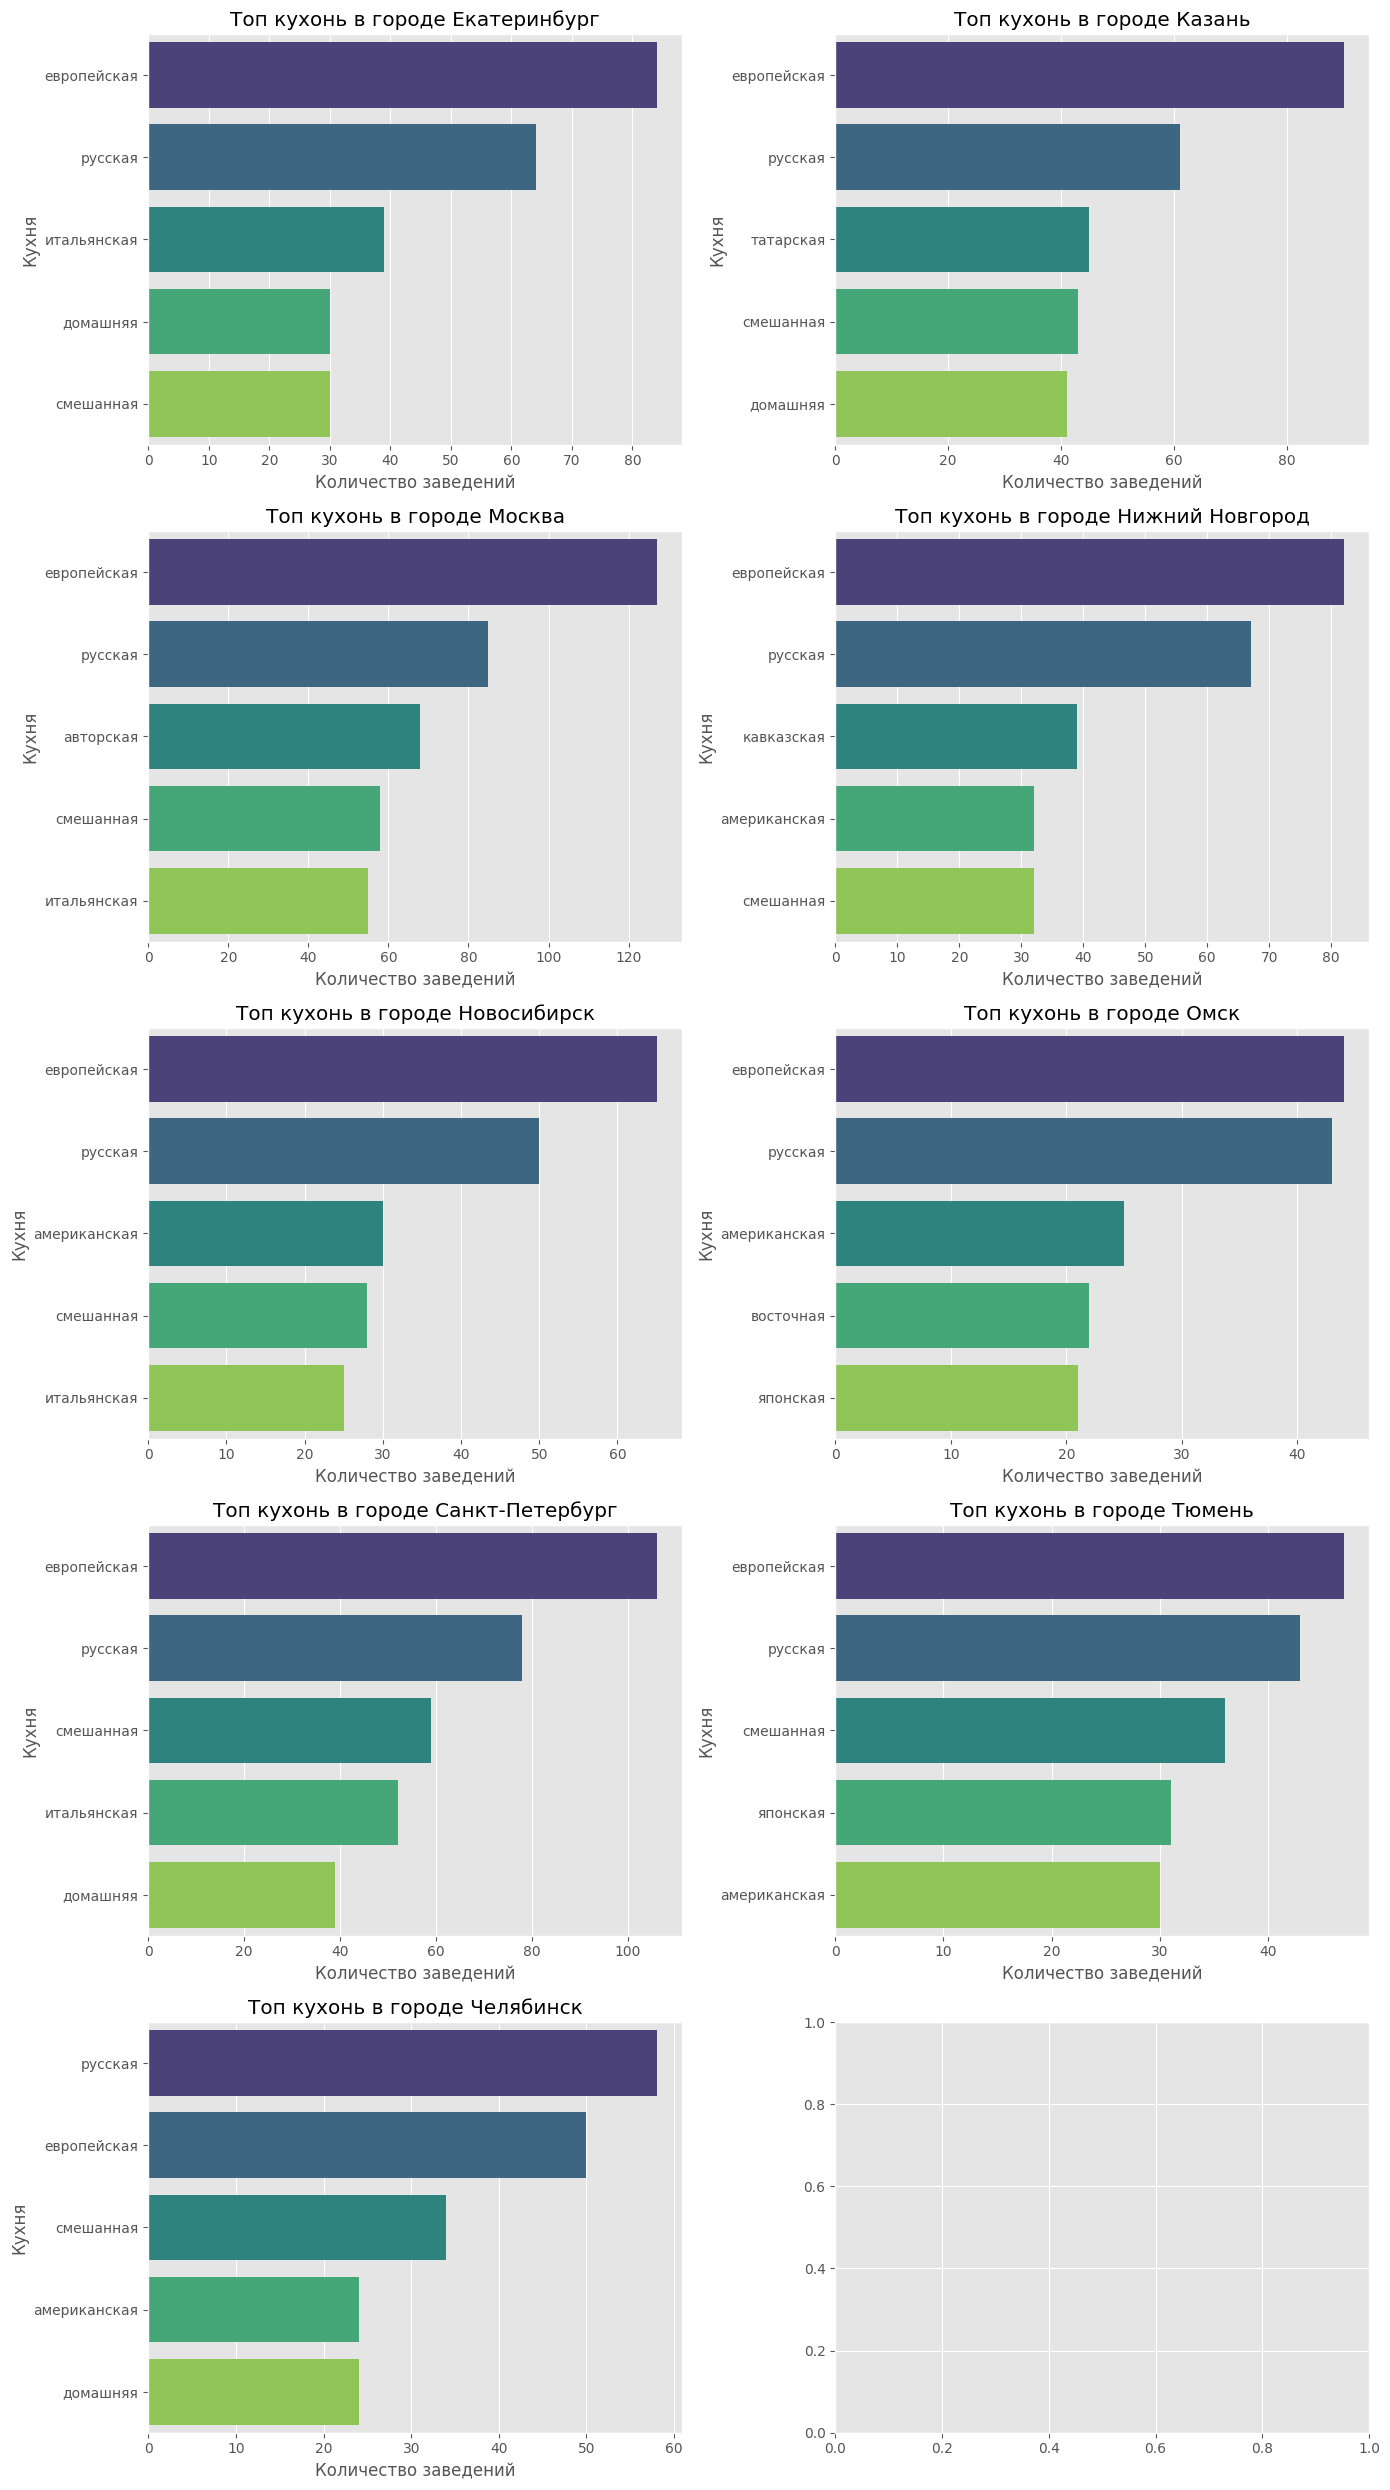

In [ ]:
import math

cities = top5_per_city['Город'].unique()
n = len(cities)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, city in enumerate(cities):
    city_data = top5_per_city[top5_per_city['Город'] == city]
    sns.barplot(data=city_data, x='count', y='Кухня', ax=axes[i], hue = city_data['Кухня'], palette='viridis')
    axes[i].set_title(f'Топ кухонь в городе {city}')
    axes[i].set_xlabel('Количество заведений')
    axes[i].set_ylabel('Кухня')

plt.tight_layout()
plt.show()

Анализ наиболее популярных кухонь в девяти российских городах выявил, что вкусовые предпочтения посетителей в целом совпадают, но имеют некоторые локальные особенности.

Европейская кухня является лидером почти во всех анализируемых городах, занимая первое место в рейтинге. Особенно выражена эта тенденция в Москве (127 заведений) и Санкт-Петербурге (106 заведений), что коррелирует с их историческими связями с Европой.

Русская кухня устойчиво занимает вторую позицию в большинстве городов, демонстрируя сохранение национальных кулинарных традиций. Интересно, что в Челябинске русская кухня выходит на первое место (58 заведений против 50 европейских), что может указывать на более консервативные вкусовые предпочтения в этом городе и спрос на понятные и недорогие блюда.

Казань - единственный город, где в топ-5 вошла национальная татарская кухня (45 заведений, третье место), что подчеркивает значение культурной идентичности в Татарстане.



4. ПРОАНАЛИЗИРУЕМ ХАРАКТЕРИСТИКИ В ЗАВИСИМОСТИ ОТ ПРИСВОЕННОГО ЗНАКА ХОРОШЕГО МЕСТА

In [ ]:
# ПРОАНАЛИЗИРУЕМ ХАРАКТЕРИСТИКИ В ЗАВИСИМОСТИ ОТ ПРИСВОЕННОГО ЗНАКА ХОРОШЕГО МЕСТА ЗАВЕДЕНИЮ

df_orgs['Хорошее_место'] = df_orgs['Знак_хорошего_места'].apply(lambda x: True if x == 'Да' else False).copy()
df_orgs['Хорошее_место'].sum()  # всего заведений с таки знаком - 496

np.int64(496)

In [ ]:
df_orgs.groupby('Знак_хорошего_места')[['Средний_чек', 'Рейтинг', 'Количество_оценок']].mean()

,Средний_чек,Рейтинг,Количество_оценок
Знак_хорошего_места,,,
Да,1441.516129,4.816734,2743.276210
Нет,889.238358,4.488319,1012.322021


Проведем тест Стьюдента для определения разницы в рейтинге и по среднему чеку в двух выборках: у заведений со знаком хорошего места и заведений, которым этот знак не присвоен

In [ ]:
from scipy.stats import ttest_ind

good_ratings = df_orgs[df_orgs['Хорошее_место']]['Рейтинг'].dropna()
other_ratings = df_orgs[~df_orgs['Хорошее_место']]['Рейтинг'].dropna()

t_stat, p_val = ttest_ind(good_ratings, other_ratings)
print(t_stat, p_val)

17.60360357402087 5.0759080405048235e-64


In [ ]:
good_ratings = df_orgs[df_orgs['Хорошее_место']]['Средний_чек'].dropna()
other_ratings = df_orgs[~df_orgs['Хорошее_место']]['Средний_чек'].dropna()

t_stat, p_val = ttest_ind(good_ratings, other_ratings)
print(t_stat, p_val)

11.261085885973806 1.8684043229439705e-28


Нулевая гипотеза отвергается в обоих тестах, можно утверждать, что заведения с меткой «Хорошее место» имеют статистически значимо более высокий средний рейтинг и также средний чек, чем заведения без этой метки

5. ТОП ПОПУЛЯРНЫХ ЗАВЕДЕНИЙ ПО ГОРОДАМ

In [ ]:
# ТОП ПОПУЛЯРНЫХ ЗАВЕДЕНИЙ ПО КОЛИЧЕСТВУ ОЦЕНОК
top_3 = df_orgs.sort_values(['Город', 'Количество_оценок'], ascending=[True, False]).groupby('Город').head(3)

for city in top_3['Город'].unique():
    print(f"\n{city}:")
    for _, row in top_3[top_3['Город'] == city].iterrows():
        print(f"  {row['Количество_оценок']:.0f} оценок — {row['Название_заведения']}")


Екатеринбург:
  10124 оценок — Мангалыч
  8277 оценок — Донна Оливия
  6568 оценок — Pan Smetan

Казань:
  12572 оценок — Иtle
  11819 оценок — Приют Холостяка
  9833 оценок — Петровский Штофъ

Москва:
  30257 оценок — Кусочки
  17799 оценок — Dr. Живаго
  16108 оценок — White Rabbit

Нижний Новгород:
  17672 оценок — Джани Ресторани
  9483 оценок — Джорджиано
  9028 оценок — Парк Культуры

Новосибирск:
  7671 оценок — Бахетле
  6423 оценок — Аджикинежаль
  4074 оценок — Горячие беляшики

Омск:
  3600 оценок — Где же кролик
  2860 оценок — Rostic's
  2448 оценок — Шашлыкоff

Санкт-Петербург:
  38628 оценок — Карл и Фридрих
  21627 оценок — Italia
  18582 оценок — ПхалиХинкали

Тюмень:
  5476 оценок — Шашлыкоff
  5468 оценок — Шашлычная № 1
  3963 оценок — ЕрмолаевЪ

Челябинск:
  8570 оценок — Журавлина
  4072 оценок — Манана Мама
  3912 оценок — Своя компания


<Axes: xlabel='Количество_оценок', ylabel='Название_заведения'>

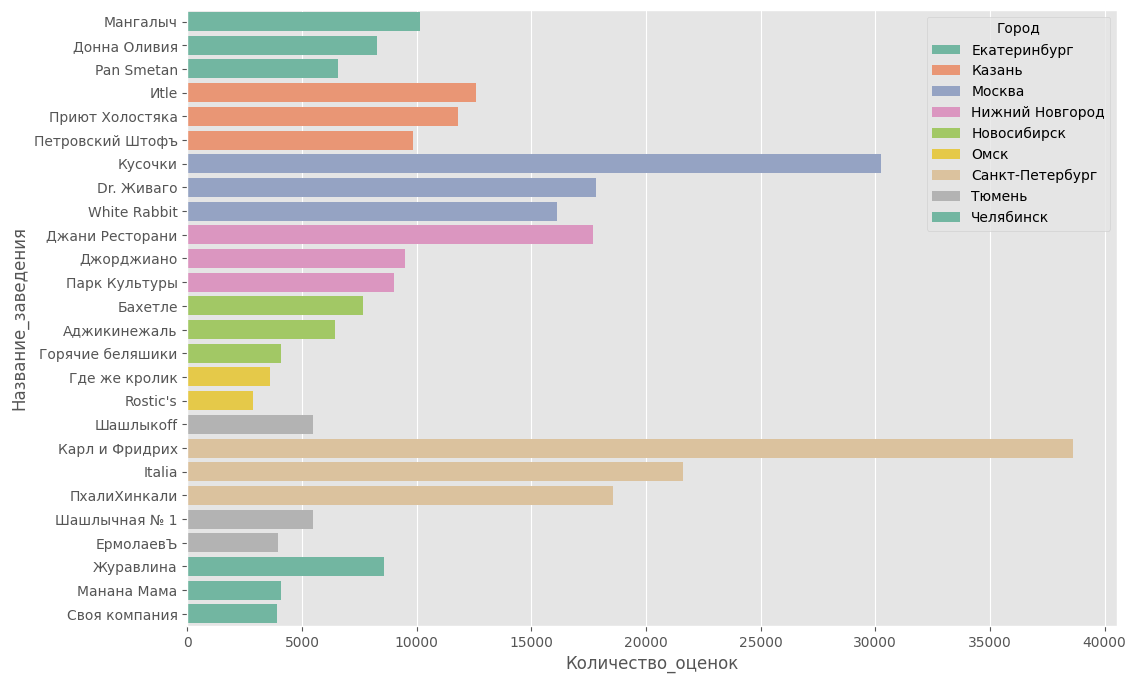

In [ ]:
top_3_plot = top_3.sort_values(by=["Город", "Количество_оценок"], ascending=[True, False])

plt.figure(figsize=(12, 8))
sns.barplot(data=top_3_plot, x="Количество_оценок", y=top_3_plot["Название_заведения"], hue="Город", palette='Set2', dodge=False)


Данные, представленные на графике выше показывают ярко выраженное лидерство Москвы и Санкт-Петербурга по заведениям с наибольшим числом оценок.

Так, абсолютным рекордсменом является ресторан "Карл и Фридрих" в Петербурге, собравший 38 628 оценок, что значительно превышает показатели других городов.

В Москве лидируют "Кусочки" с 30 257 оценками, а в Нижнем Новгороде и Казани лучшие заведения набрали от 12 до 17 тысяч оценок.

В остальных городах-миллионниках, таких как Екатеринбург, Новосибирск, Тюмень, Челябинск и Омск, самые популярные точки имеют существенно меньшее внимание - от 3 до 10 тысяч оценок.

Это подтверждает очевидный тренд: пользовательская активность и, как следствие, видимость заведений максимально сконцентрированы в двух столицах. При этом в регионах в топ часто входят заведения с локальным колоритом или специализацией на определённой кухне, например, шашлычные или грузинские рестораны.

6. ТОП ПОПУЛЯРНЫХ ЛОКАЦИЙ (УЛИЦ) ДЛЯ РАЗМЕЩЕНИЯ ЗАВЕДЕНИЙ ПО ГОРОДАМ

In [ ]:
# ПРОАНАЛИЗИРУЕМ ПОПУЛЯРНЫЕ ЛОКАЦИИ ДЛЯ РАЗМЕЩЕНИЯ ЗАВЕДЕНИЙ ПО ГОРОДАМ

def street(stroka):
    return stroka.split(',')[0]
df_orgs['Улица'] = df_orgs['Адрес'].apply(street)

for city in df_orgs.dropna(subset=['Улица', 'Город'])['Город'].unique():
    streets = df_orgs[(df_orgs['Город']==city) & (df_orgs['Улица'].notna())]['Улица'].value_counts().head(3)
    if not streets.empty:
        print(f"\n{city}:")
        for street, count in streets.items():
            print(f"  {street} — {count}")


Екатеринбург:
  ул. 8 Марта — 19
  ул. Малышева — 17
  просп. Ленина — 10

Казань:
  просп. Победы — 11
  Чистопольская ул. — 10
  ул. Баумана — 8

Москва:
  просп. Мира — 5
  Кутузовский просп. — 5
  Пятницкая ул. — 4

Нижний Новгород:
  Большая Покровская ул. — 24
  просп. Гагарина — 12
  Рождественская ул. — 8

Новосибирск:
  Красный просп. — 17
  ул. Ленина — 15
  ул. Гоголя — 10

Омск:
  просп. Карла Маркса — 12
  ул. 70 лет Октября — 10
  Омск — 9

Санкт-Петербург:
  Невский просп. — 15
  Лиговский просп. — 11
  Московский просп. — 7

Тюмень:
  ул. Республики — 17
  ул. Ленина — 9
  ул. Пермякова — 9

Челябинск:
  ул. Кирова — 11
  просп. Ленина — 9
  Тернопольская ул. — 8


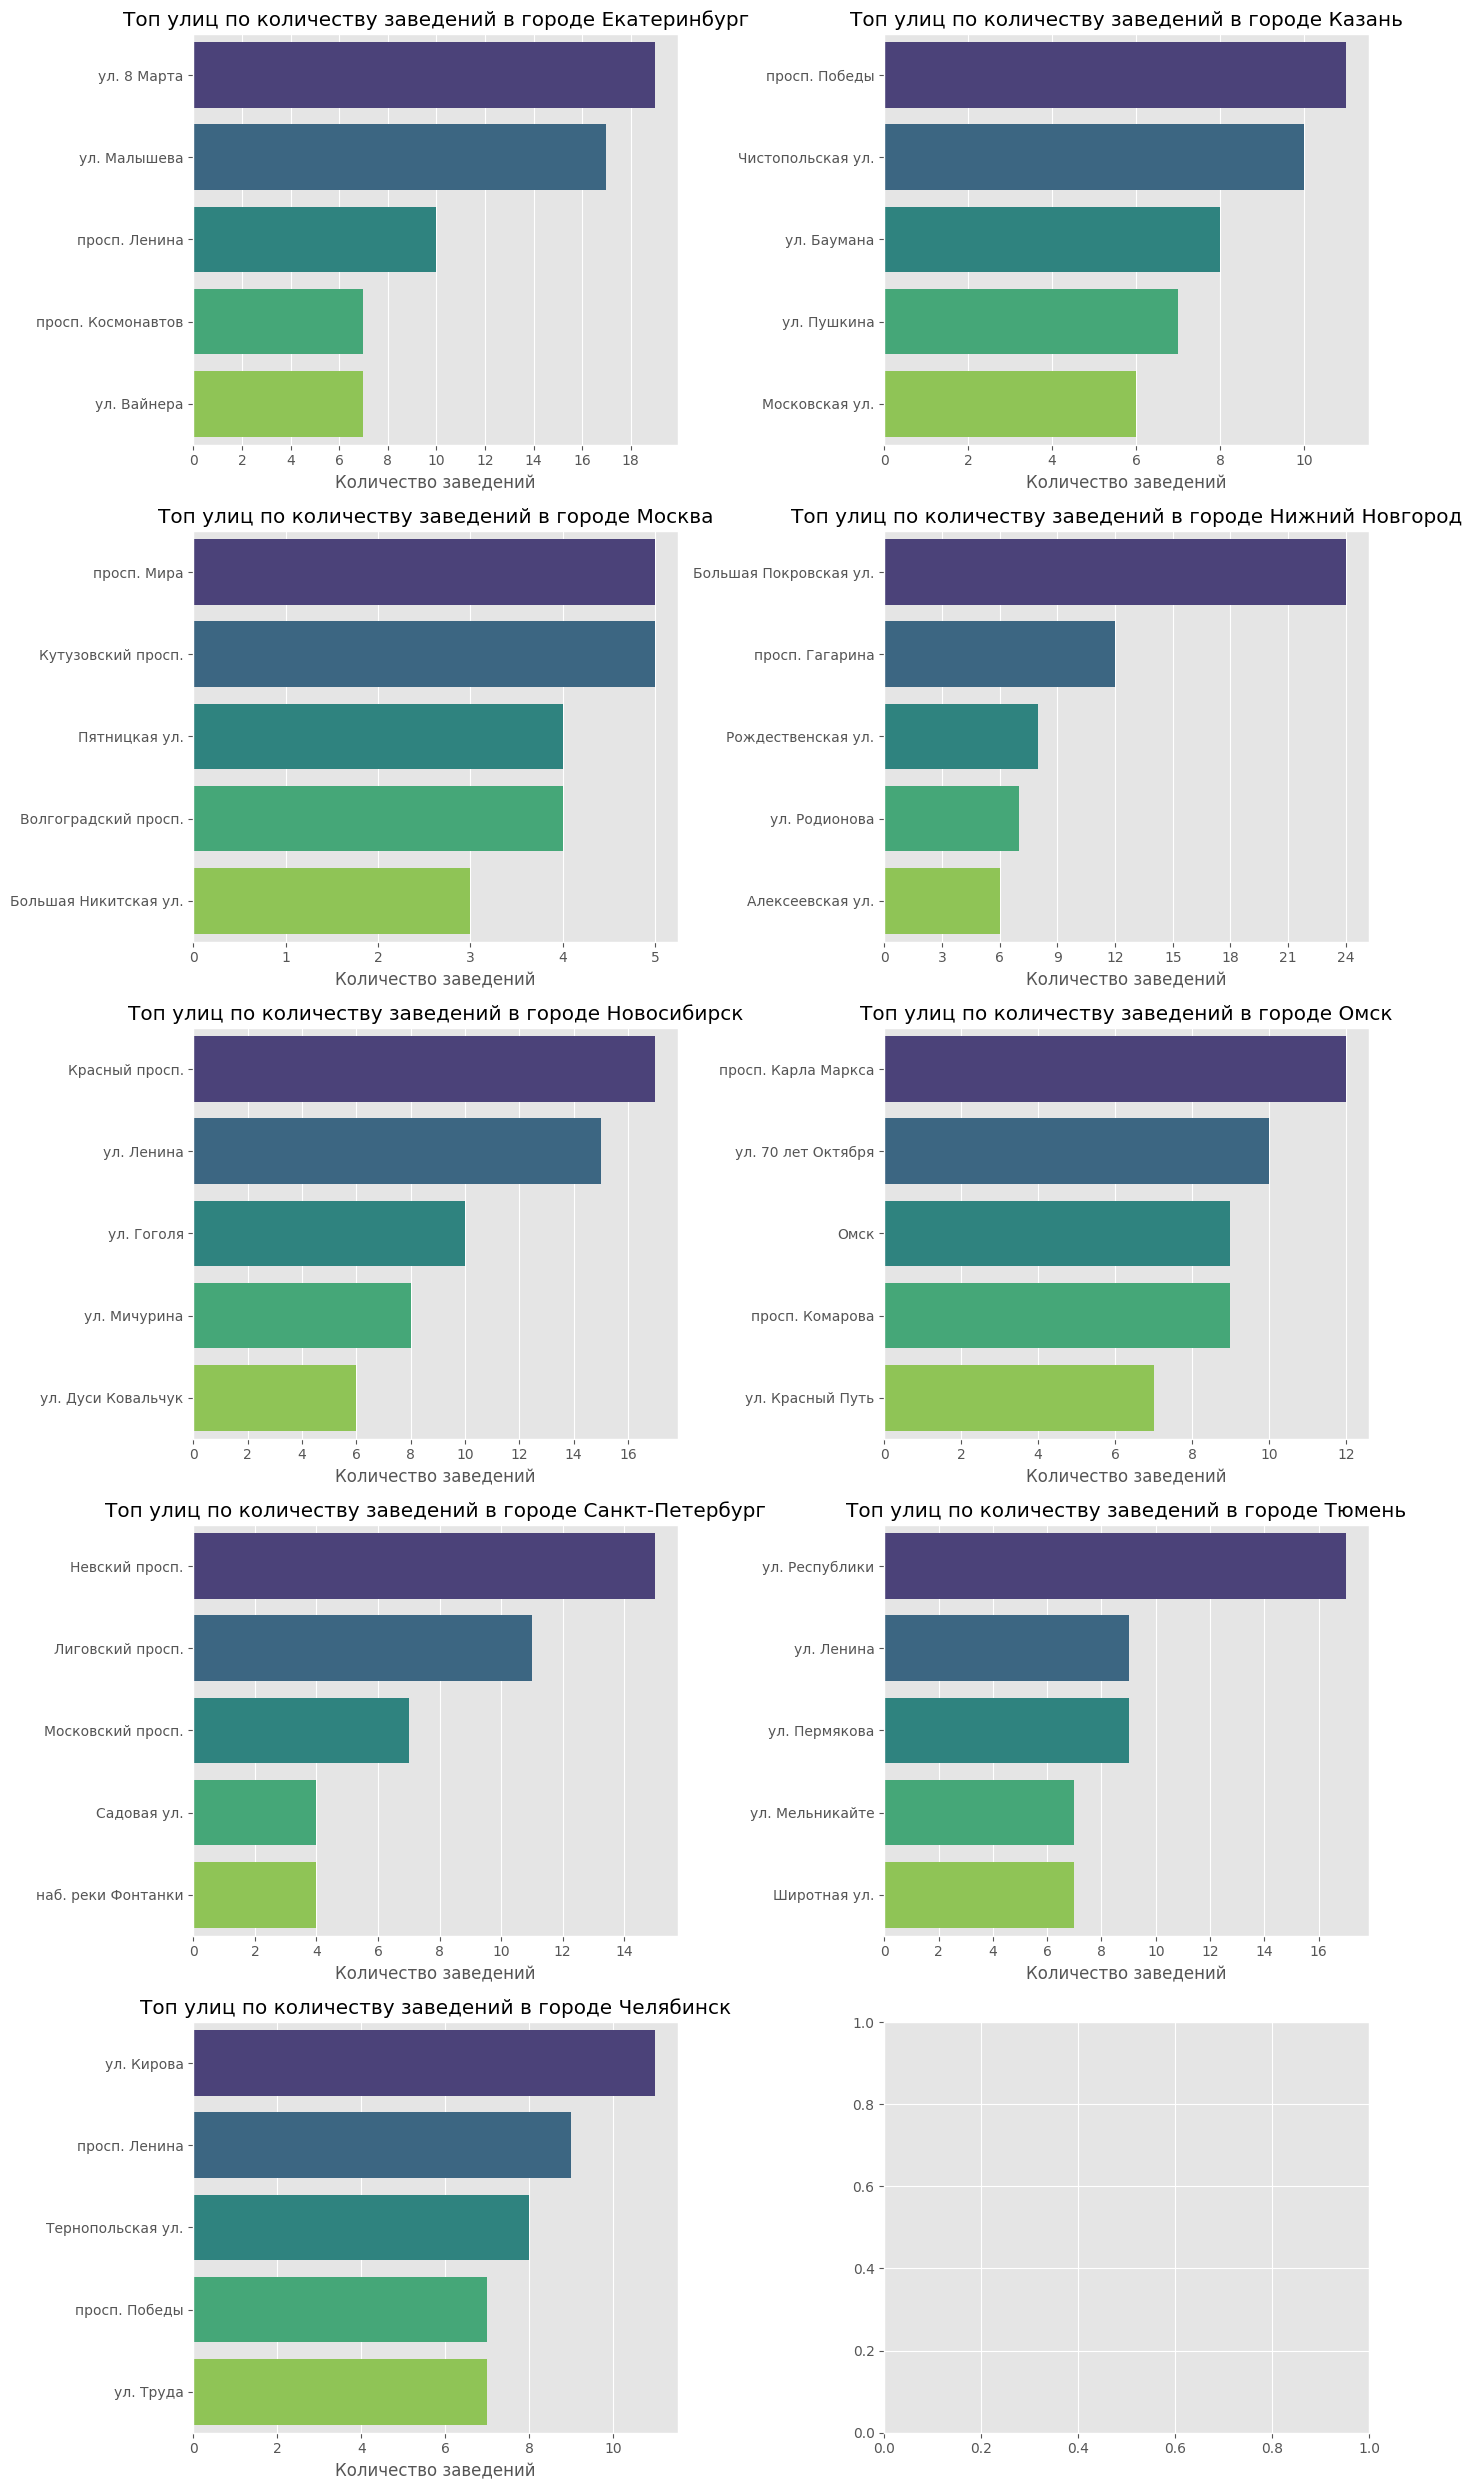

In [ ]:
import math
import matplotlib.ticker as mtick
cities = df_orgs['Город'].dropna().unique()
n = len(cities)
cols = 2
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(14, 5 * rows))
axes = axes.flatten() if n > 1 else [axes]

for i, city in enumerate(cities):
    city_data = df_orgs[df_orgs['Город'] == city]['Улица'].value_counts().head(5).reset_index()
    city_data.columns = ['Улица', 'count']
    sns.barplot(data=city_data, x='count', y='Улица', ax=axes[i], hue=city_data['Улица'], palette='viridis')
    axes[i].set_title(f'Топ улиц по количеству заведений в городе {city}')
    axes[i].set_xlabel('Количество заведений')
    axes[i].set_ylabel('')
    axes[i].xaxis.set_major_locator(mtick.MaxNLocator(integer=True))

plt.tight_layout()
plt.show()

На графике видно распределение заведений по главным улицам анализируемых городов.

Лидирует Нижний Новгород, где на Большой Покровской улице сосредоточено 24 заведения, что явлется макcимумом среди всех городов.

В Екатеринбурге, Новосибирске и Тюмени также выделяются ключевые улицы с высокой концентрацией бизнеса: ул. 8 Марта (19 заведений), Красный проспект (17) и ул. Республики (17).

В Москве и Санкт-Петербурге цифры скромнее, так, на самых популярных улицах всего от 5 до 15 заведений.

В целом, в регионах чётко прослеживается централизация коммерческой активности вокруг одной-двух основных улиц, часто носящих исторические или символические названия, такие как Ленина, Победы или Кирова.

7. ИНДЕКС ДОРОГОВИЗНЫ ЗАВЕДЕНИЯ (СООТНОШЕНИЕ СРЕДНЕГО ЧЕКА ПО ГОРОДУ И СРЕДНЕГО ЧЕКА ОТДЕЛЬНОГО ЗАВЕДЕНИЯ)

In [ ]:
# ВЫЧИСЛИМ СРЕДНИЙ ЧЕК ПО КАЖДОМУ ГОРОДУ
city_avg_check = df_orgs.groupby('Город')['Средний_чек'].mean()
df_orgs['Средний_чек_по_городу'] = df_orgs['Город'].map(city_avg_check)
df_orgs['Индекс_дороговизны'] = df_orgs['Средний_чек'] / df_orgs['Средний_чек_по_городу']
df_orgs.head(5)

,Название_заведения,Ссылка_на_карточку_заведения,Теги,Тип_заведения,Особенности_заведения,Кухня,Средний_чек,Рейтинг,Описание,Адрес,Город,Телефон,Сайт,Социальные_сети,Знак_хорошего_места,Количество_оценок,Хорошее_место,Улица,Средний_чек_по_городу,Индекс_дороговизны
0,Кофейня Ü,https://yandex.ru/maps/org/kofeynya_/110196569...,"Кофейня, Кондитерская, Кафе",NaN,"настольные игры, своя пекарня, бесплатная парк...","европейская, паназиатская, вегетарианская, вег...",630.0,4.8,"Кофейня Ü — это место, где вы можете насладить...","ул. Куйбышева, 44А, Екатеринбург, этаж 1",Екатеринбург,+7 (967) 639-22-92,http://duocoffee.ru/,"https://t.me/tiptopbrew, https://vk.com/duoekb",Нет,1000.0,False,ул. Куйбышева,949.415,0.663567
1,Сытный дворик,https://yandex.ru/maps/org/sytny_dvorik/981543...,Кафе,NaN,NaN,NaN,500.0,1.0,NaN,"ул. Металлургов, 84, Екатеринбург • этаж 0",Екатеринбург,NaN,NaN,NaN,Нет,67.0,False,ул. Металлургов,949.415,0.526640
2,Патриот,https://yandex.ru/maps/org/patriot/59010897337/,"Кафе, Столовая, Ресторан",NaN,"своя пекарня, местоположение у воды, кулинария","грузинская, европейская, белорусская, кавказск...",300.0,4.3,"Кафе «Патриот» — это место, где можно вкусно и...","ул. Горького, 63, Екатеринбург, этаж 1",Екатеринбург,+7 (900) 037-98-08,NaN,https://wa.me/79000379808?text=%D0%9E%D0%B1%D1...,Нет,423.0,False,ул. Горького,949.415,0.315984
3,Ням-ням,https://yandex.ru/maps/org/nyam_nyam/42552263222/,"Кафе, Ресторан",NaN,NaN,NaN,500.0,4.3,NaN,"ул. Софьи Ковалевской, 3, Екатеринбург",Екатеринбург,+7 (999) 811-03-49,NaN,NaN,Нет,10.0,False,ул. Софьи Ковалевской,949.415,0.526640
4,Britannia,https://yandex.ru/maps/org/britannia/1761871877/,"Бар, Ресторан",пивной ресторан,есть банкетный зал,"европейская, английская",2000.0,5.0,"Бар Britannia — это атмосферное заведение, сти...","ул. Вайнера, 64А, Екатеринбург",Екатеринбург,+7 (912) 654-48-88,http://britannia-pub.ru/,http://vk.com/club100993741,Нет,2858.0,False,ул. Вайнера,949.415,2.106560


8. СЕГМЕНТАЦИЯ ЗАВЕДЕНИЙ ПО СРЕДНЕМУ ЧЕКУ


In [ ]:
# ДЛЯ НАЧАЛА ПОСМОТРИМ НА КВАНТИЛИ РАСПРЕДЕЛЕНИЯ СРЕДНЕГО ЧЕКА
# найдем квантили для низкого, среднего и высокого ценового сегмента

low = np.quantile(df_orgs['Средний_чек'], 0.33)
med = np.quantile(df_orgs['Средний_чек'], 0.66)
print(low, med)

# определю функцию для сегментации заведений
def segment(stroka):
    if stroka <= low:
        return 'Низкий'
    elif low < stroka <= med:
        return 'Средний'
    elif stroka > med:
        return 'Высокий'

df_orgs['Ценовой_сегмент'] = df_orgs['Средний_чек'].apply(segment)
df_orgs.head()

500.0 1200.0


,Название_заведения,Ссылка_на_карточку_заведения,Теги,Тип_заведения,Особенности_заведения,Кухня,Средний_чек,Рейтинг,Описание,Адрес,...,Телефон,Сайт,Социальные_сети,Знак_хорошего_места,Количество_оценок,Хорошее_место,Улица,Средний_чек_по_городу,Индекс_дороговизны,Ценовой_сегмент
0,Кофейня Ü,https://yandex.ru/maps/org/kofeynya_/110196569...,"Кофейня, Кондитерская, Кафе",NaN,"настольные игры, своя пекарня, бесплатная парк...","европейская, паназиатская, вегетарианская, вег...",630.0,4.8,"Кофейня Ü — это место, где вы можете насладить...","ул. Куйбышева, 44А, Екатеринбург, этаж 1",...,+7 (967) 639-22-92,http://duocoffee.ru/,"https://t.me/tiptopbrew, https://vk.com/duoekb",Нет,1000.0,False,ул. Куйбышева,949.415,0.663567,Средний
1,Сытный дворик,https://yandex.ru/maps/org/sytny_dvorik/981543...,Кафе,NaN,NaN,NaN,500.0,1.0,NaN,"ул. Металлургов, 84, Екатеринбург • этаж 0",...,NaN,NaN,NaN,Нет,67.0,False,ул. Металлургов,949.415,0.526640,Низкий
2,Патриот,https://yandex.ru/maps/org/patriot/59010897337/,"Кафе, Столовая, Ресторан",NaN,"своя пекарня, местоположение у воды, кулинария","грузинская, европейская, белорусская, кавказск...",300.0,4.3,"Кафе «Патриот» — это место, где можно вкусно и...","ул. Горького, 63, Екатеринбург, этаж 1",...,+7 (900) 037-98-08,NaN,https://wa.me/79000379808?text=%D0%9E%D0%B1%D1...,Нет,423.0,False,ул. Горького,949.415,0.315984,Низкий
3,Ням-ням,https://yandex.ru/maps/org/nyam_nyam/42552263222/,"Кафе, Ресторан",NaN,NaN,NaN,500.0,4.3,NaN,"ул. Софьи Ковалевской, 3, Екатеринбург",...,+7 (999) 811-03-49,NaN,NaN,Нет,10.0,False,ул. Софьи Ковалевской,949.415,0.526640,Низкий
4,Britannia,https://yandex.ru/maps/org/britannia/1761871877/,"Бар, Ресторан",пивной ресторан,есть банкетный зал,"европейская, английская",2000.0,5.0,"Бар Britannia — это атмосферное заведение, сти...","ул. Вайнера, 64А, Екатеринбург",...,+7 (912) 654-48-88,http://britannia-pub.ru/,http://vk.com/club100993741,Нет,2858.0,False,ул. Вайнера,949.415,2.106560,Высокий


In [ ]:
df_orgs.groupby('Ценовой_сегмент')[['Рейтинг', 'Хорошее_место', 'Количество_оценок']].agg(['mean', 'std', 'min', 'max'])

Рейтинг                     Хорошее_место                   \
                     mean       std  min  max          mean       std    min   
Ценовой_сегмент                                                                
Высокий          4.760000  0.212208  3.7  5.0      0.510345  0.500469  False   
Низкий           4.372304  0.424239  1.0  5.0      0.111851  0.315393  False   
Средний          4.716811  0.279840  2.8  5.0      0.329289  0.470363  False   

                      Количество_оценок                             
                  max              mean          std  min      max  
Ценовой_сегмент                                                     
Высокий          True       2942.712644  3586.288272  7.0  38628.0  
Низкий           True        599.237017   995.230340  3.0   9505.0  
Средний          True       1582.616984  2572.883741  3.0  21627.0

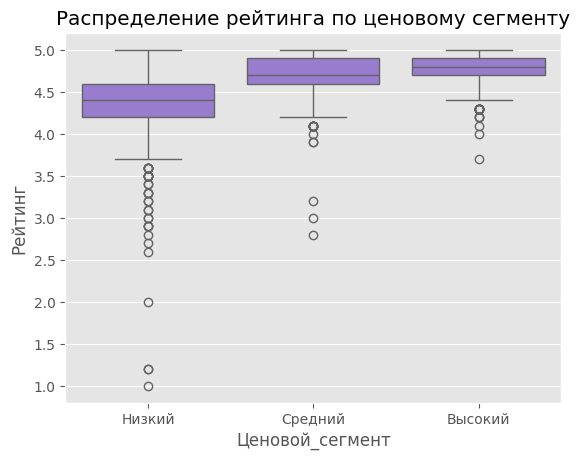

In [ ]:
sns.boxplot(data=df_orgs, x='Ценовой_сегмент', y='Рейтинг', order=['Низкий', 'Средний', 'Высокий'], color = '#9370DB')
plt.title('Распределение рейтинга по ценовому сегменту')
plt.show()

Чётко прослеживается прямая зависимость между ценовым сегментом и ключевыми показателями. Так, заведения высокого ценового сегмента демонстрируют лучшие результаты: у них самый высокий средний рейтинг (4.76), наибольшая доля признанных "хорошими местами" (51%) и максимальное среднее количество оценок (около 2943).

Заведения среднего сегмента близки к высокому по рейтингу (4.72), но имеют заметно меньшие показатели популярности и признания.

Низкий ценовой сегмент значительно уступает по всем метрикам: средний рейтинг 4.37, лишь 11% заведений считаются "хорошими местами" и минимальное среднее количество оценок (около 599). Это указывает на то, что более высокая цена в данном случае коррелирует с лучшим качеством, большей популярностью и доверием аудитории.

Посмотрим на корреляцию переменных внутри ценового сегмента

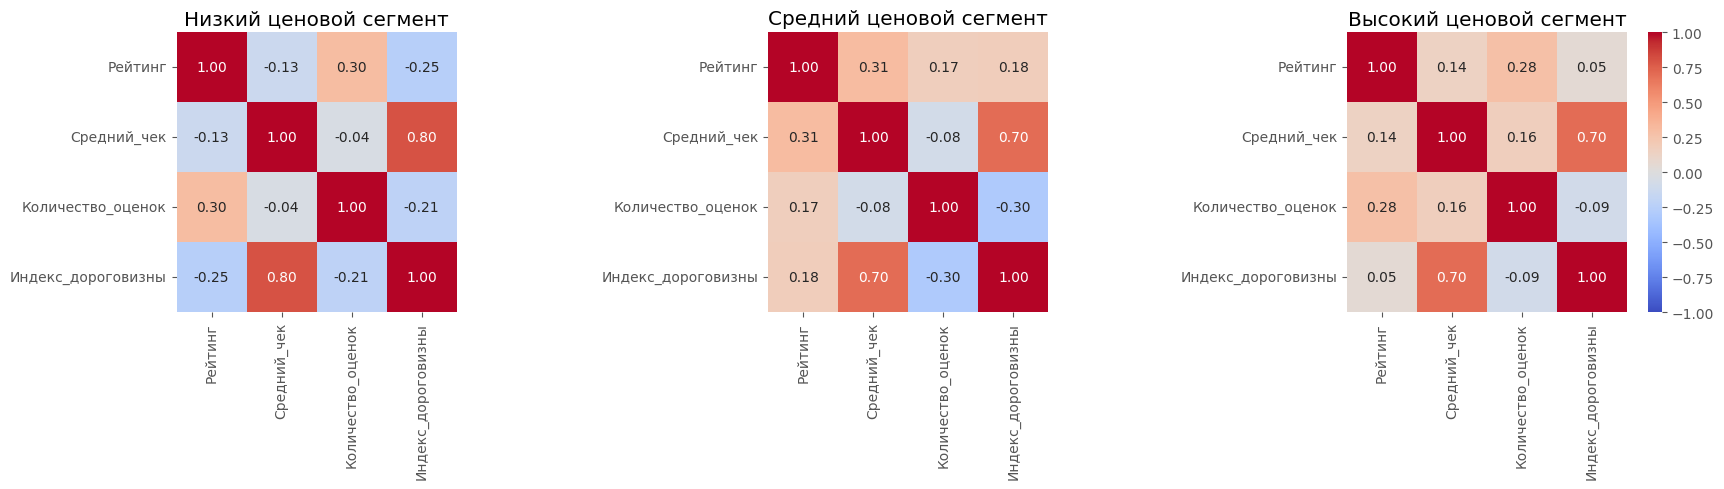

In [ ]:
numeric_cols = [
    'Рейтинг',
    'Средний_чек',
    'Количество_оценок',
    'Индекс_дороговизны']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, segment in enumerate(['Низкий', 'Средний', 'Высокий']):
    subset = df_orgs[df_orgs['Ценовой_сегмент'] == segment][numeric_cols]
    subset = subset.dropna()
    corr_matrix = subset.corr()
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap='coolwarm',
        vmin=-1, vmax=1,
        square=True,
        ax=axes[i],
        cbar=i == 2
    )
    axes[i].set_title(f'{segment} ценовой сегмент')

plt.tight_layout()
plt.show()

Рейтинг в недорогих заведениях слабее всего связан с ценой и количеством отзывов - повышение стоимости воспринимается негативно, и даже большое число отзывов не гарантирует высоких оценок. Клиенты очень чувствительны к цене и оценивают в первую очередь доступность, а не качество;

В среднем сегменте лучшие оценки получают заведения с оправданным соотношением цены и качества: рейтинг умеренно растёт вместе со средним чеком, но более дорогие места реже получают много отзывов;

В премиальном сегменте цена практически не влияет на рейтинг - клиенты ожидают высокого уровня вне зависимости от стоимости. Количество отзывов также мало влияет на оценку, а рейтинг формируется более требовательной и узкой аудиторией.

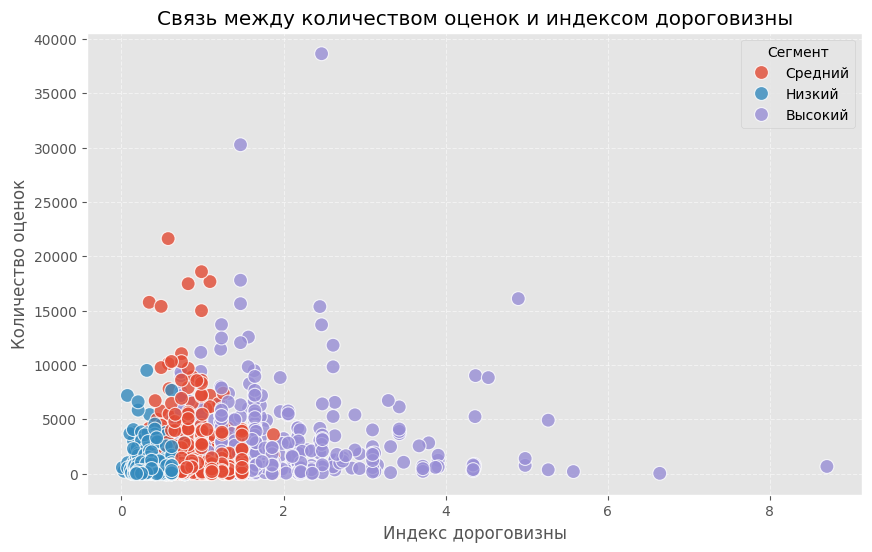

Индекс_дороговизны  Количество_оценок
Ценовой_сегмент                                                          
Высокий         Индекс_дороговизны            1.000000          -0.089476
                Количество_оценок            -0.089476           1.000000
Низкий          Индекс_дороговизны            1.000000          -0.211906
                Количество_оценок            -0.211906           1.000000
Средний         Индекс_дороговизны            1.000000          -0.303029
                Количество_оценок            -0.303029           1.000000

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df_orgs,
    x='Индекс_дороговизны',
    y='Количество_оценок',
    hue='Ценовой_сегмент',
    s=100,
    alpha=0.8
)
plt.title('Связь между количеством оценок и индексом дороговизны')
plt.xlabel('Индекс дороговизны')
plt.ylabel('Количество оценок')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Сегмент')
plt.show()

df_orgs.groupby('Ценовой_сегмент')[['Индекс_дороговизны', 'Количество_оценок']].corr()

Наблюдается слабая отрицательная корреляция между индексом дороговизны и количеством оценок во всех сегментах — особенно выраженная в среднем и низком сегменте (r ≈ -0.30 и r ≈ -0.21).

In [ ]:
# сохраним предобработанный датасет
df_orgs.to_csv('df_orgs_new.csv', index=False, encoding='utf-8')

ЗАГРУЖАЕМ ИТОГОВЫЕ ДАТАСЕТЫ

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
df_final = pd.read_csv('/content/drive/MyDrive/ПРОЕКТ ПАЙТОН/df_final.csv')
df_orgs_new = pd.read_csv('/content/drive/MyDrive/ПРОЕКТ ПАЙТОН/df_orgs_new.csv')

Mounted at /content/drive


In [ ]:
print(df_final.shape)
df_final.head(3)

(4787, 11)


,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва,Тональность,Тематика,Отзыв_очищенный
0,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Заходил на бизнес-ланч. Все понравилось. Был в...,5.0,Юрий,2019-07-19,70,позитивный,еда,заходить бизнес ланч понравиться вкусный грибн...
1,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Понравилось, был до ремонта и после, сейчас од...",5.0,Александр Парыгин,2023-11-24,67,позитивный,атмосфера,понравиться ремонт однозначно атмосферный
2,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"После ремонта очень красиво, свежо, понравилас...",5.0,Айслу,2023-01-02,88,позитивный,ремонт,ремонт очень красиво свежо понравиться атмосфе...


In [ ]:
print(df_orgs_new.shape)
df_orgs_new.head(3)

(1763, 21)


,Название_заведения,Ссылка_на_карточку_заведения,Теги,Тип_заведения,Особенности_заведения,Кухня,Средний_чек,Рейтинг,Описание,Адрес,...,Телефон,Сайт,Социальные_сети,Знак_хорошего_места,Количество_оценок,Хорошее_место,Улица,Средний_чек_по_городу,Индекс_дороговизны,Ценовой_сегмент
0,Кофейня Ü,https://yandex.ru/maps/org/kofeynya_/110196569...,"Кофейня, Кондитерская, Кафе",NaN,"настольные игры, своя пекарня, бесплатная парк...","европейская, паназиатская, вегетарианская, вег...",630.0,4.8,"Кофейня Ü — это место, где вы можете насладить...","ул. Куйбышева, 44А, Екатеринбург, этаж 1",...,+7 (967) 639-22-92,http://duocoffee.ru/,"https://t.me/tiptopbrew, https://vk.com/duoekb",Нет,1000.0,False,ул. Куйбышева,949.415,0.663567,Средний
1,Сытный дворик,https://yandex.ru/maps/org/sytny_dvorik/981543...,Кафе,NaN,NaN,NaN,500.0,1.0,NaN,"ул. Металлургов, 84, Екатеринбург • этаж 0",...,NaN,NaN,NaN,Нет,67.0,False,ул. Металлургов,949.415,0.526640,Низкий
2,Патриот,https://yandex.ru/maps/org/patriot/59010897337/,"Кафе, Столовая, Ресторан",NaN,"своя пекарня, местоположение у воды, кулинария","грузинская, европейская, белорусская, кавказск...",300.0,4.3,"Кафе «Патриот» — это место, где можно вкусно и...","ул. Горького, 63, Екатеринбург, этаж 1",...,+7 (900) 037-98-08,NaN,https://wa.me/79000379808?text=%D0%9E%D0%B1%D1...,Нет,423.0,False,ул. Горького,949.415,0.315984,Низкий


In [ ]:
# ФОРМИРУЕМ ИТОГОВЫЙ ДАТАСЕТ

# оставляем в датасете по организациям только заведения тюмени
df_tum = df_orgs_new[df_orgs_new['Город'] == 'Тюмень']


In [ ]:
common_cols = ['Название_заведения', 'Ссылка_на_карточку_заведения', 'Город']

df_all = df_final.merge(df_tum, on=common_cols, how='left')
print(df_all.shape)

df_all.info()

(4787, 29)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4787 entries, 0 to 4786
Data columns (total 29 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Название_заведения            4787 non-null   object 
 1   Ссылка_на_карточку_заведения  4787 non-null   object 
 2   Город                         4787 non-null   object 
 3   Отзыв                         4787 non-null   object 
 4   Оценка_отзыва                 4787 non-null   float64
 5   Автор_отзыва                  4787 non-null   object 
 6   Дата_отзыва                   4787 non-null   object 
 7   Длина_отзыва                  4787 non-null   int64  
 8   Тональность                   4787 non-null   object 
 9   Тематика                      4787 non-null   object 
 10  Отзыв_очищенный               4783 non-null   object 
 11  Теги                          4757 non-null   object 
 12  Тип_заведения                 2117 non-null   objec

In [ ]:
df_all['id_заведения'] = df_all['Название_заведения'] + ' | ' + df_all['Ссылка_на_карточку_заведения'] # поскольку есть филлиалы, то создадим новую переменную - уникальный айди заведения

df_all['Тональность_число'] = df_all['Тональность'].map({'позитивный': 1, 'нейтральный': 0, 'негативный': -1})
df_all.head()

,Название_заведения,Ссылка_на_карточку_заведения,Город,Отзыв,Оценка_отзыва,Автор_отзыва,Дата_отзыва,Длина_отзыва,Тональность,Тематика,...,Социальные_сети,Знак_хорошего_места,Количество_оценок,Хорошее_место,Улица,Средний_чек_по_городу,Индекс_дороговизны,Ценовой_сегмент,id_заведения,Тональность_число
0,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Заходил на бизнес-ланч. Все понравилось. Был в...,5.0,Юрий,2019-07-19,70,позитивный,еда,...,https://vk.com/artichoke.karaoke,Нет,1085.0,False,ул. Ленина,903.294416,1.882,Высокий,Artichoke | https://yandex.ru/maps/org/articho...,1
1,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Понравилось, был до ремонта и после, сейчас од...",5.0,Александр Парыгин,2023-11-24,67,позитивный,атмосфера,...,https://vk.com/artichoke.karaoke,Нет,1085.0,False,ул. Ленина,903.294416,1.882,Высокий,Artichoke | https://yandex.ru/maps/org/articho...,1
2,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"После ремонта очень красиво, свежо, понравилас...",5.0,Айслу,2023-01-02,88,позитивный,ремонт,...,https://vk.com/artichoke.karaoke,Нет,1085.0,False,ул. Ленина,903.294416,1.882,Высокий,Artichoke | https://yandex.ru/maps/org/articho...,1
3,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,"Все отлично, Лучший Ведущий",5.0,Кирилл Шадеркин,2020-03-28,27,позитивный,ведущий,...,https://vk.com/artichoke.karaoke,Нет,1085.0,False,ул. Ленина,903.294416,1.882,Высокий,Artichoke | https://yandex.ru/maps/org/articho...,1
4,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,Очень понравился новый интерьер клуба. Как все...,5.0,Денис С.,2023-02-10,258,позитивный,клуб,...,https://vk.com/artichoke.karaoke,Нет,1085.0,False,ул. Ленина,903.294416,1.882,Высокий,Artichoke | https://yandex.ru/maps/org/articho...,1


In [ ]:
# схлопнем датасет

grouped = df_all.groupby('id_заведения').agg(
    Название_заведения=('Название_заведения', 'first'),
    Ссылка_на_карточку_заведения=('Ссылка_на_карточку_заведения', 'first'),
    Город=('Город', 'first'),
    Средняя_тональность=('Тональность_число', 'mean'),
    Средний_чек=('Средний_чек', 'first'),
    Рейтинг=('Рейтинг', 'first'),
    Количество_оценок = ('Количество_оценок', 'first'),
    Расположение=('Улица', 'first'),
    Хорошее_место = ('Хорошее_место', 'first'),
    Индекс_дороговизны=('Индекс_дороговизны', 'first'),
    Ценовой_сегмент=('Ценовой_сегмент', 'first')
).reset_index(drop=True)
grouped.head()

,Название_заведения,Ссылка_на_карточку_заведения,Город,Средняя_тональность,Средний_чек,Рейтинг,Количество_оценок,Расположение,Хорошее_место,Индекс_дороговизны,Ценовой_сегмент
0,Artichoke,https://yandex.ru/maps/org/artichoke/1364604455/,Тюмень,0.366667,1700.0,4.7,1085.0,ул. Ленина,False,1.882000,Высокий
1,Banzai,https://yandex.ru/maps/org/banzai/179459511420/,Тюмень,0.920000,6000.0,4.8,39.0,ул. Грибоедова,True,6.642353,Высокий
2,Brew's Lee,https://yandex.ru/maps/org/brew_s_lee/22816535...,Тюмень,0.566667,2000.0,4.7,198.0,Первомайская ул.,False,2.214118,Высокий
3,Brooklyn Bowl,https://yandex.ru/maps/org/brooklyn_bowl/16061...,Тюмень,0.466667,960.0,5.0,1141.0,ул. Федюнинского,False,1.062776,Средний
4,Brunch,https://yandex.ru/maps/org/brunch/145824888608/,Тюмень,0.333333,899.0,4.4,288.0,ул. Пермякова,False,0.995246,Средний


In [ ]:
grouped.shape

(170, 11)

Построим пузырьковую диаграмму по заведениям.

In [ ]:
import plotly.express as px
grouped.dropna(inplace=True)

fig = px.scatter(
    grouped,
    x='Средний_чек',
    y='Рейтинг',
    size='Количество_оценок',
    color='Средняя_тональность',
    hover_name='Название_заведения',
    color_continuous_scale='RdYlGn',
    size_max=50,
    title='Заведения Тюмени'
)

fig.update_layout(
    xaxis_title='Средний чек (руб.)',
    yaxis_title='Рейтинг',
    legend_title='Средняя тональность'
)

fig.show()

КЛАСТЕРИЗАЦИЯ ЗАВЕДЕНИЙ

In [ ]:
# СТАНДАРТИЗИРУЕМ ДАННЫЕ ЧТОБЫ НЕ БЫЛО ПЕРЕКОСОВ В СТОРОНУ ПЕРЕМЕННЫХ С БОЛЕЕ ВЫСОКИМИ ЗНАЧЕНИЯМИ

from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

X = grouped[['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']].copy()
X['Количество_оценок'] = np.log1p(X['Количество_оценок'])
X_new = MinMaxScaler().fit_transform(X)


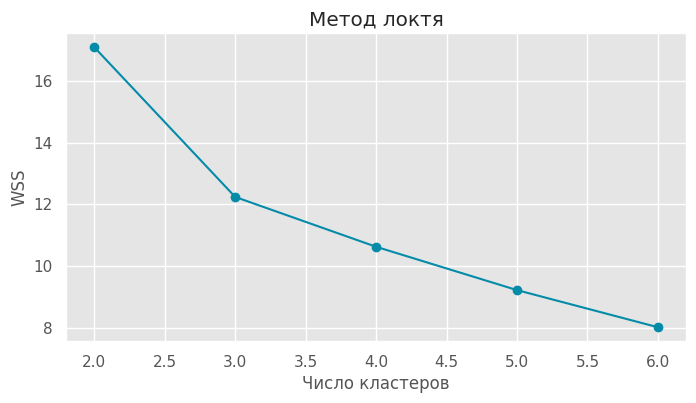

In [ ]:
from sklearn.cluster import KMeans

wss = []
K_range = range(2, 7)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_new)
    wss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, wss, marker='o', color = '#048ba8')
plt.title('Метод локтя')
plt.xlabel('Число кластеров')
plt.ylabel('WSS')
plt.show()

Согласно графику, оптимальное количество кластеров равно 3

In [ ]:
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
grouped['Кластер'] = kmeans.fit_predict(X_new)

grouped = grouped.loc[X.index].copy()

In [ ]:
cluster_summary = grouped.groupby('Кластер')[['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']].mean()
print(cluster_summary)

         Средняя_тональность   Рейтинг  Количество_оценок  Индекс_дороговизны
Кластер                                                                      
0                   0.193922  4.173333         275.111111            0.604060
1                   0.718956  4.606944         166.888889            1.051014
2                   0.613649  4.767308        1466.692308            1.446415


Посмотрим как выглядят кластеры, для этого используем метод главных компонент

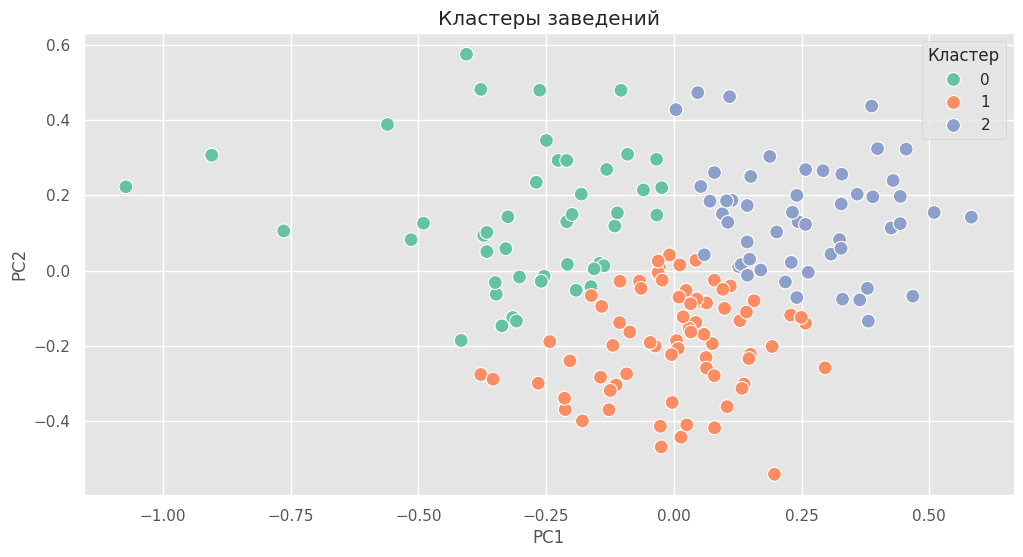

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_new)

plt.figure(figsize=(12, 6))
sns.scatterplot(
    x=X_pca[:, 0], y=X_pca[:, 1],
    hue=grouped.loc[X.index, 'Кластер'],
    palette='Set2',
    s=100
)
plt.title(f'Кластеры заведений')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Кластер')
plt.show()

Посмотрим на средние значения по кластерам

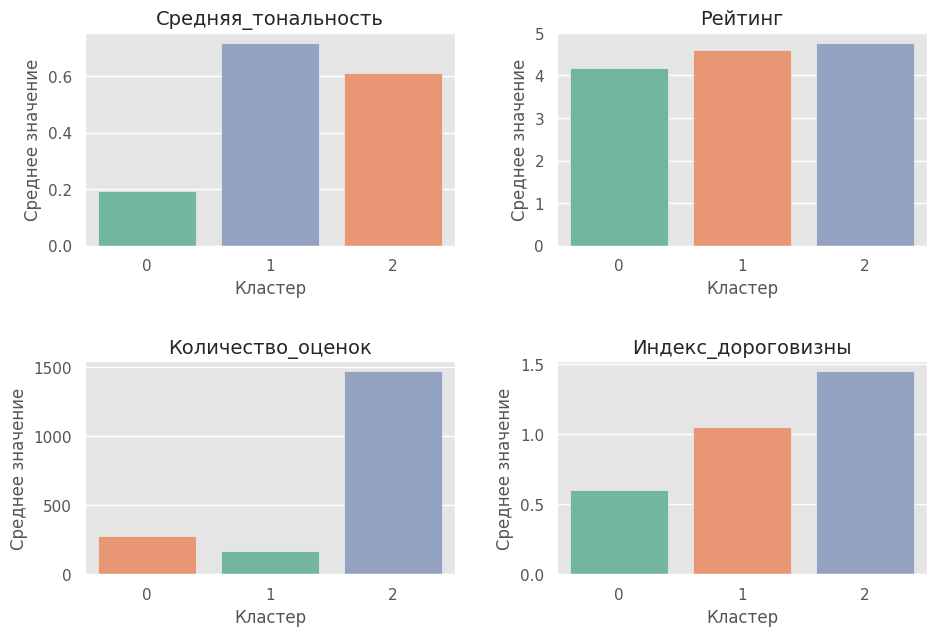

In [ ]:
cluster_profile = grouped.groupby('Кластер')[['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']].mean().reset_index()
list_cols = ['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']

fig, axes = plt.subplots(2, 2, figsize=(10, 7))
axes = axes.flatten()

for i, j in enumerate(list_cols):
    ax = axes[i]
    sns.barplot(
        data=cluster_profile,
        x='Кластер',
        y=j,
        hue = j,
        palette='Set2',
        ax=ax
    )
    ax.set_title(f'{j}', fontsize=14)
    ax.set_xlabel('Кластер')
    ax.set_ylabel('Среднее значение')
    ax.legend_.remove()

plt.tight_layout(pad=3.0)
plt.show()

In [ ]:
cluster_profile

,Кластер,Средняя_тональность,Рейтинг,Количество_оценок,Индекс_дороговизны
0,0,0.193922,4.173333,5.620803,0.604060
1,1,0.718956,4.606944,5.123302,1.051014
2,2,0.613649,4.767308,7.291447,1.446415


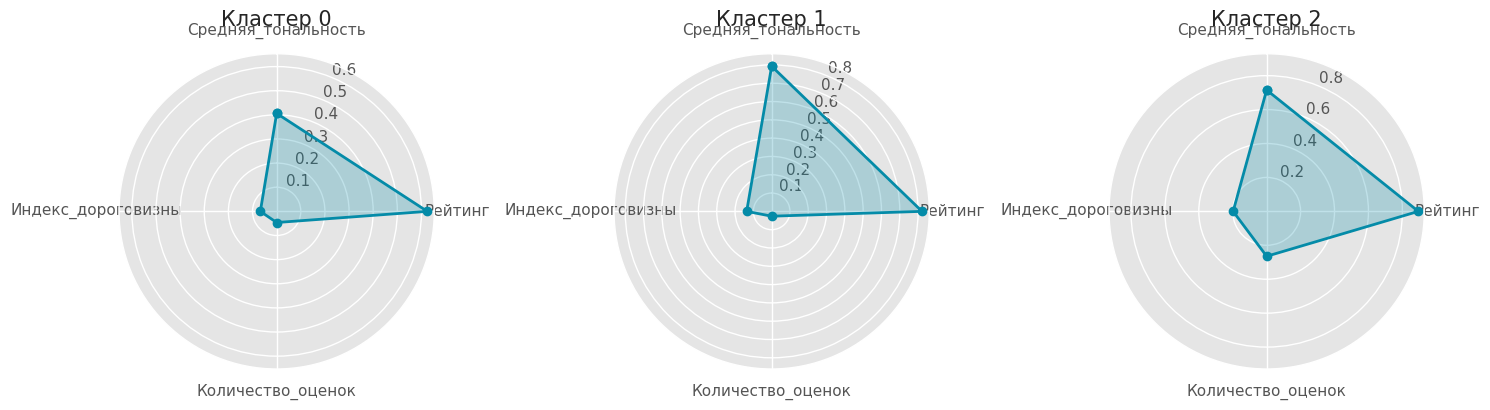

In [ ]:
# РАДАР КАРТА
grouped[['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']] = MinMaxScaler().fit_transform(grouped[['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']])
cluster_means = grouped.groupby('Кластер')[['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']].mean().reset_index()

labels = ['Средняя_тональность', 'Рейтинг', 'Количество_оценок', 'Индекс_дороговизны']

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]
fig, axes = plt.subplots(1, 3, subplot_kw=dict(polar=True), figsize=(15, 5))

for i, cluster_id in enumerate([0, 1, 2]):
    ax = axes[i]
    row = cluster_means[cluster_means['Кластер'] == cluster_id].iloc[0]

    values = row[labels].tolist()
    values += values[:1]
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), labels)
    ax.plot(angles, values, 'o-', linewidth=2, label=f'Кластер {cluster_id}', color = '#048ba8')
    ax.fill(angles, values, alpha=0.25, color = '#048ba8')
    ax.set_title(f'Кластер {cluster_id}', size=15, pad=20)
    ax.grid(True)

plt.tight_layout()
plt.show()

Посмотрим на заведения, которые попали в кластер 0

In [ ]:
', '.join(set(grouped[grouped['Кластер'] == 0]['Название_заведения']))

"Борщ, Суши Босс, Гриль хаус, Rostic's, Ольга, Охаси, Green, Subway — Subjoy, Амали, Brunch, Плов хауз, Лаваш, Бургер Кинг, Столовая, Урарту, Sashimi, Сочень, SweetOk, Галерея Суши, Pizza Mia, Суши-нка, Эталон, Время вкуса, Пельмешка, Воккер, ДЕД ХО, Чилли-Вилли, Бургер Кинг Авто, Шаурма, Pizza & Pasta, Крошка Картошка, Шашлыкоff, Duner от мясника, Good Food, Пицца-Маркет, Hai Pho, Додо Пицца"

Посмотрим на заведения, которые попали в кластер 1

In [ ]:
', '.join(set(grouped[grouped['Кластер'] == 1]['Название_заведения']))

"Тарелку съел, Столовая 38, Каприччио, Uno, Британия, Роял, Кодавари, Макуме, Среда, Шпачек, Метехи, Завтрак, Mangal, Лаваш, Dogma bar, Бигхот, Крым, Ретро, Гамарджоба, Столовая, Brew's Lee, Суши мастер, Техникум, Суши-Маркет, Дусти, Пельменная, ЧебурекМи, Марио Пиццальдо, Talk, Дом Профсоюзов, Шаверма Time, Мэджик Ролл, SweetOk, Максим, Здрасте, Шашлык Ассорти 72, Народная, Кофе Он, Уютный уголок, Optimist Coffee, Joy, Вкусняшка, Мазенка, Свои, Garden Coffee, Чилаут, Пекарня Казаровская, Optimist coffee, Шашлык-Маркет, Суаре, Banzai, Довезука.рф, Садбарги Худжанди, Magic Roll, Твори!, Nож и Мясо, Щи&Борщи, Другой бар, Шаурма на углях, Halal, Хурма, Блинчики, Пышечная"

Посмотрим на заведения, которые попали в кластер 2

In [ ]:
', '.join(set(grouped[grouped['Кластер'] == 2]['Название_заведения']))

"Шашлычная № 1, Шаурма по-братски, Столица деревень, Brooklyn Bowl, Хинкальная Кацо, Чико, Mestia, TomYumBar, Кофе Брют, Бурум, Как Мы Любим, Стара Прага, Mikado, Pizza Express, Бургер Кинг, Чито Грито, Noodle wok & pasta, Шашлык72, Суши-Маркет, Izakaya by SoupRamen, Лодка, Кружка, Ван Гоги, Гурман, Контора, Киоко Изакая, Artichoke, Восточная долина, Мама тесто, SweetOk, Максим, Тамрико, Супрамен, Фреска, Марабда, Баши, Туркестан, Посейдон, Ржавый ДЕД, Гузаль, Шашлыкоff, Бухара, Harat's Irish Pub, Мидийное место, Царица роллов, Оазис, ЕрмолаевЪ, Своя компания, Додо Пицца, СибирьСибирь"

# Характеристика кластеров
**Кластер 0** \
Этот кластер характеризуется низкой средней тональностью отзывов и средним рейтингом, при этом объекты здесь имеют самый низкий индекс дороговизны и небольшое количество оценок. Это, как правило, недорогие и малоизвестные объекты, вызывающие у пользователей смешанные ощущения. \
\
**Кластер 1** \
Объекты этого кластера демонстрируют максимально высокую тональность (в данной выборке) и высокий рейтинг, однако при этом имеют минимальное число оценок. стоимость варьируется на среднем уровне. Такой кластер представляет собой качественные, но пока не слишком популярные варианты, которые хорошо воспринимаются теми, кто ими уже пользовался. \
\
**Кластер 2** \
Кластер включает объекты с высоким рейтингом, положительной тональностью и наиболее высоким количеством оценок. Индекс дороговизны также максимальный. Это популярные, востребованные и более дорогие объекты, которые стабильно получают хорошие отзывы и привлекают большое число пользователей.
